# USDJPY Event-Time Implied-Vol Stack — 1W ATM, calendar-position only

One pair (**USDJPY**), one tenor (**1W ATM implied vol**), one flat multiple-testing
correction. The question is narrow and the answer is meant to be *seen*:

> For each high-relevance scheduled USD or JPY release, what does USDJPY 1-week implied
> volatility do on each of the trading days from five before the release to five after,
> relative to an ordinary non-event day?

This is a smaller, faster, more plot-forward companion to
`usd_event_time_iv_template.ipynb`. That notebook covers 8 pairs, ~270 candidate event
types and a three-tier FDR hierarchy, and spends most of its length defending
methodological choices. This one is built to show shapes on one pair quickly.

## What this notebook deliberately does NOT do

**No Granger causality, and no `surprise_z` / event-outcome data anywhere.**

Both omissions are one decision, not an oversight. Granger causality tests whether the
history of one stochastic series improves prediction of another. It needs a driver with
genuine uncertainty in its own past. **Surprise magnitude** — how far the actual print
landed from the survey — would have been exactly that driver, but modelling
release *content* is out of scope for this study.

What is left as the driver is **calendar position**: the number of trading days until or
since a scheduled release. That variable is *deterministic*. The 2027 FOMC dates are
already published. A sequence known years in advance has no innovation for Granger to
extract, and "the calendar predicts vol" is not a testable information-flow claim — it is
a lookup. Running Granger against it would produce numbers, and every one of them would be
uninterpretable. This is the same reasoning that excluded Granger from the reference
notebook.

So the entire inferential weight sits on three instruments that **are** valid against a
deterministic calendar regressor:

1. **The event-time stack** — a day-dummy regression, relative days -5 to +5, giving the
   day-by-day shape.
2. **A calendar-matched permutation test** — placebo release dates with the same count,
   the same weekday mix, drawn from days USDJPY actually traded.
3. **TDMI** — mutual information per relative day, an assumption-free dependence check
   that catches effects a mean-shift coefficient is blind to.

The columns `surprise`, `surprise_z`, `actual_num`, `survey_num`, `prior_num` and
`revised_num` are never loaded. The `usecols` filter in the load cell is the enforcement,
not a comment.

## Inputs, and why the **1W** tenor

- **Events** — `G10_events_merged_1997-2026.csv`, columns `datetime_utc`, `ccy`, `event`,
  `relevance` only.
- **Vol** — `ATM_vol_long_panel.csv`, filtered to `pair == "USDJPY"` and `tenor == "1W"`.

**On the tenor.** The vol panel already carries a `tenor` column spanning 1D, 1W, 2W, 1M,
2M, 3M, 6M, 1Y. Selecting 1W is a **filter on data already in hand** — no new extraction,
no new pull, no re-clean. Worth stating plainly because prior notebooks in this project
used 1D and 1M and neither used 1W:

| tenor | why not / why here |
|---|---|
| **1D** | Used by `usd_event_time_iv_template.ipynb`. It is the most event-reactive tenor, but also the noisiest — overnight vol carries heavy weekend-decay and day-of-week structure that has nothing to do with any release. Across 8 pairs that noise averages out; on **one** pair it does not. |
| **1M** | Used in the earlier single-pair work. A one-month quote spans ~21 trading days, so a single release's contribution is averaged against ~20 other days. The very thing being measured gets smoothed away. |
| **1W** | **This notebook.** Five trading days — wide enough to damp the 1D noise, narrow enough that one release is a material fraction of the window. The untested middle ground, tried here on purpose. |

A consequence of the tenor choice shows up later and is worth flagging now: a weekly quote
responds more slowly and more diffusely than an overnight one, which is why the event
window here is `[-5, +5]` rather than the reference notebook's `[-7, +5]`.

In [1]:
import os
import re
import time
import traceback
from contextlib import contextmanager

import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 300)

# ---------------------------------------------------------------- paths
EVENTS_PATH     = "/Users/aksharaa/Downloads/G10_events_merged_1997-2026.csv"
VOL_PATH        = "/Users/aksharaa/Downloads/ATM_vol_long_panel.csv"
CHECKPOINT_DIR  = "/Users/aksharaa/Downloads/_checkpoints"
RUN_LOG_PATH    = "/Users/aksharaa/Downloads/_run_log.txt"
RUN_SUMMARY_PATH = "/Users/aksharaa/Downloads/_run_summary.txt"
OUT_FULL_PATH   = "/Users/aksharaa/Downloads/usdjpy_event_stack_full.csv"
OUT_SUMMARY_PATH = "/Users/aksharaa/Downloads/usdjpy_event_stack_summary.csv"

# ---------------------------------------------------------------- named constants
PAIR                 = "USDJPY"
TENOR                = "1W"          # see markdown above -- a filter, not a new extraction
EVENT_CCYS           = ("USD", "JPY")  # either leg can move this pair

RELEVANCE_CUTOFF     = 90.0          # Bloomberg relevance; scale inspected before this was set
MIN_OCCURRENCES      = 30            # applied to CLEAN episodes, not raw calendar hits
OVERLAP_THRESHOLD    = 0.90          # same-release-family de-dup

SCREEN_HALF_WIDTH    = 2             # step 5 screen: event day +/- 2 trading days
PRE_DAYS             = 5             # step 6 stack: relative days -5 ...
POST_DAYS            = 5             #                        ... +5
STACK_KS             = list(range(-PRE_DAYS, POST_DAYS + 1))
MAX_WINDOW_SPAN_DAYS = 25            # 11 trading days must not span a data gap
MAX_LAG_GAP_DAYS     = 7             # lag1 is stale if yesterday's quote is >7 calendar days old

N_PERMUTATIONS       = 200
PERM_SEED            = 20260805
FDR_ALPHA            = 0.05
MI_NEIGHBORS         = 3
MI_RANDOM_STATE      = 0

OOS_HOLDOUT_FRAC     = 0.20          # step 10: most recent 20% of episodes held out
CI_Z                 = 1.96

PILOT_N_EVENTS       = 3             # pilot runs at FULL N_PERMUTATIONS, never a reduced count
PILOT_WARN_SECONDS   = 45 * 60       # warn-and-proceed threshold, not an abort threshold
FORCE_RECOMPUTE      = False         # True = ignore existing per-event checkpoints

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ---------------------------------------------------------------- run log / stage guard
RUN_T0 = time.time()
STAGE_ERRORS = []        # (stage name, message) -- surfaced in the final run summary
SKIPPED_EVENTS = {}      # event key -> reason, for the final run summary

with open(RUN_LOG_PATH, "w") as fh:
    fh.write(f"=== usdjpy_event_stack_causal run started {pd.Timestamp.now()} ===\n")


def log(msg, level="INFO"):
    """Append to the plain-text run log AND print. Nobody is watching the notebook live,
    so the log file is the primary channel and stdout is the convenience copy."""
    line = f"[{pd.Timestamp.now():%Y-%m-%d %H:%M:%S}] {level:5s} {msg}"
    with open(RUN_LOG_PATH, "a") as fh:
        fh.write(line + "\n")
    print(line)


@contextmanager
def stage(name, fatal=False):
    """Wrap a major stage: log the failure, record it, and continue where that is safe.

    `fatal=True` is reserved for stages where continuing would silently produce
    meaningless downstream numbers (loading the data, the pilot sanity check)."""
    log(f"stage start: {name}")
    t0 = time.time()
    try:
        yield
    except Exception as exc:
        STAGE_ERRORS.append((name, f"{type(exc).__name__}: {exc}"))
        log(f"stage FAILED: {name} -- {type(exc).__name__}: {exc}", "ERROR")
        with open(RUN_LOG_PATH, "a") as fh:
            fh.write(traceback.format_exc() + "\n")
        if fatal:
            raise
    else:
        log(f"stage done : {name} ({time.time() - t0:.1f}s)")


log(f"constants: relevance>={RELEVANCE_CUTOFF}, MIN_OCCURRENCES={MIN_OCCURRENCES}, "
    f"screen=+/-{SCREEN_HALF_WIDTH}d, stack=[{-PRE_DAYS},{POST_DAYS}], "
    f"N_PERMUTATIONS={N_PERMUTATIONS}, FORCE_RECOMPUTE={FORCE_RECOMPUTE}")

[2026-08-05 22:35:07] INFO  constants: relevance>=90.0, MIN_OCCURRENCES=30, screen=+/-2d, stack=[-5,5], N_PERMUTATIONS=200, FORCE_RECOMPUTE=False


## 1. Load & validate

Fail-loud, same philosophy as the reference notebook: a missing column, a missing pair or a
missing tenor stops the run rather than triggering a silent fallback path. This is the one
stage marked `fatal=True` — everything downstream is meaningless without it.

The events schema check asks for exactly the four columns this notebook reads. Asserting on
`surprise_z` would be asserting on a column the design deliberately never touches.

In [2]:
EVENTS_COLS_REQUIRED = {"datetime_utc", "ccy", "event", "relevance"}
VOL_COLS_REQUIRED    = {"date", "pair", "tenor", "atm_vol"}

with stage("1. load & validate", fatal=True):
    for path in (EVENTS_PATH, VOL_PATH):
        if not os.path.isfile(path):
            raise FileNotFoundError(
                f"Required input missing: {path}. This notebook uses exactly these two "
                "pre-cleaned files and will not search elsewhere on disk."
            )

    # usecols is the enforcement of the no-outcome-data rule: surprise / surprise_z /
    # actual_num / survey_num / prior_num / revised_num are never read into memory.
    events_raw = pd.read_csv(EVENTS_PATH, usecols=lambda c: c in EVENTS_COLS_REQUIRED)
    vol_raw    = pd.read_csv(VOL_PATH)

    for name, df, expected in [("events", events_raw, EVENTS_COLS_REQUIRED),
                               ("vol", vol_raw, VOL_COLS_REQUIRED)]:
        missing = expected - set(df.columns)
        if missing:
            raise KeyError(f"{name} file is missing required column(s): {sorted(missing)}")

    forbidden = {"surprise", "surprise_z", "actual_num", "survey_num", "prior_num", "revised_num"}
    leaked = forbidden & set(events_raw.columns)
    if leaked:
        raise AssertionError(f"outcome columns leaked into the events frame: {sorted(leaked)}")

    if PAIR not in set(vol_raw["pair"].unique()):
        raise ValueError(f"{PAIR} absent from the vol panel.")
    if TENOR not in set(vol_raw["tenor"].unique()):
        raise ValueError(f"tenor {TENOR!r} absent from the vol panel; available: "
                         f"{sorted(vol_raw['tenor'].unique())}")

    events = events_raw.copy()
    # mixed sub-second precision across vendor files -- a single ambiguous row poisons
    # parsing of the whole column without format="mixed".
    events["datetime_utc"] = pd.to_datetime(events["datetime_utc"], format="mixed")
    events["date"] = events["datetime_utc"].dt.normalize()
    events = events[events["ccy"].isin(EVENT_CCYS)].copy()

    if events["relevance"].isna().any():
        n_na = int(events["relevance"].isna().sum())
        log(f"{n_na} {'/'.join(EVENT_CCYS)} event rows have no relevance score; they cannot "
            "clear the relevance cutoff and are dropped.", "WARN")
        events = events[events["relevance"].notna()].copy()

    log(f"events: {len(events)} rows across {events['event'].nunique()} "
        f"{'/'.join(EVENT_CCYS)} event types, {events['date'].min():%Y-%m-%d} to "
        f"{events['date'].max():%Y-%m-%d}")
    log(f"vol   : {len(vol_raw)} rows, {vol_raw['pair'].nunique()} pairs, "
        f"tenors {sorted(vol_raw['tenor'].unique())}")

[2026-08-05 22:35:07] INFO  stage start: 1. load & validate


[2026-08-05 22:35:08] INFO  events: 16880 rows across 49 USD/JPY event types, 1997-01-02 to 2026-07-01
[2026-08-05 22:35:08] INFO  vol   : 865893 rows, 17 pairs, tenors ['1D', '1M', '1W', '1Y', '2M', '2W', '3M', '6M']
[2026-08-05 22:35:08] INFO  stage done : 1. load & validate (0.3s)


## 2. The IV panel — `log(atm_vol)` at 1W, plus its lag

The outcome is `log_atm_vol = np.log(atm_vol)` in **levels**, and `log_atm_vol_lag1` enters
every regression as an AR(1) control.

- **Log**, so a coefficient reads as a proportional effect: `0.03` is "about 3% higher
  implied vol", which stays comparable across the 2.4–46 vol range this series has covered
  since 1995.
- **Levels, not changes**, because the question is "where does vol *sit* on day k", which is
  what a template consumer needs to look up. The AR(1) term is what keeps a level regression
  from simply re-reading vol's own persistence as an event effect.

Two data-quality guards, both of which matter more on a single pair than they did pooled
across eight:

1. `atm_vol > 0` everywhere, else `log` silently manufactures `-inf`.
2. `lag1` is only usable when yesterday's quote is within `MAX_LAG_GAP_DAYS` calendar days.
   Across a two-week hole in the panel, "yesterday's vol" is not yesterday's vol, and an
   AR(1) coefficient fitted through those rows is fitted on a different variable.

In [3]:
with stage("2. IV panel", fatal=True):
    vol = vol_raw.copy()
    vol["date"] = pd.to_datetime(vol["date"])
    v = (vol[(vol["pair"] == PAIR) & (vol["tenor"] == TENOR)]
         .sort_values("date").drop_duplicates("date"))

    if v.empty:
        raise ValueError(f"no rows for {PAIR} at tenor {TENOR}")
    if not (v["atm_vol"].dropna() > 0).all():
        raise ValueError("atm_vol contains non-positive quotes -- log() would produce -inf. "
                         "Stopping rather than dropping rows quietly.")
    if v["atm_vol"].isna().any():
        raise ValueError("atm_vol contains NaN quotes in the filtered panel.")

    panel = pd.DataFrame({"atm_vol": v["atm_vol"].values},
                         index=pd.DatetimeIndex(v["date"].values, name="date"))
    panel["log_atm_vol"] = np.log(panel["atm_vol"])
    panel["log_atm_vol_lag1"] = panel["log_atm_vol"].shift(1)
    panel["lag_gap_days"] = panel.index.to_series().diff().dt.days.values
    panel["usable"] = panel["log_atm_vol_lag1"].notna() & (panel["lag_gap_days"] <= MAX_LAG_GAP_DAYS)

    N_PANEL      = len(panel)
    PANEL_DATES  = panel.index.values
    Y_ALL        = panel["log_atm_vol"].values
    LAG_ALL      = panel["log_atm_vol_lag1"].values
    USABLE       = panel["usable"].values
    WEEKDAY      = panel.index.dayofweek.values

    log(f"{PAIR} {TENOR} panel: {N_PANEL} trading days, "
        f"{panel.index.min():%Y-%m-%d} to {panel.index.max():%Y-%m-%d}; "
        f"{int(USABLE.sum())} rows usable (lag1 present and fresh).")
    print(panel[["atm_vol", "log_atm_vol", "log_atm_vol_lag1"]].describe()
          .to_string(float_format=lambda x: f"{x:8.4f}"))

    # window-completeness mask: a position may anchor an episode only if the whole
    # [-5, +5] block is usable and does not straddle a gap. The +/-2 screen window is
    # nested inside it, so one mask serves both steps.
    complete_mask = np.zeros(N_PANEL, dtype=bool)
    for i in range(PRE_DAYS, N_PANEL - POST_DAYS):
        lo, hi = i - PRE_DAYS, i + POST_DAYS
        if not USABLE[lo:hi + 1].all():
            continue
        span = (PANEL_DATES[hi] - PANEL_DATES[lo]) / np.timedelta64(1, "D")
        if span <= MAX_WINDOW_SPAN_DAYS:
            complete_mask[i] = True
    log(f"window-complete anchor positions: {int(complete_mask.sum())} of {N_PANEL} "
        f"({complete_mask.mean():.1%})")

[2026-08-05 22:35:08] INFO  stage start: 2. IV panel
[2026-08-05 22:35:08] INFO  USDJPY 1W panel: 7828 trading days, 1995-12-06 to 2026-07-01; 7824 rows usable (lag1 present and fresh).
        atm_vol  log_atm_vol  log_atm_vol_lag1
count 7828.0000    7828.0000         7827.0000
mean    10.2126       2.2606            2.2606
std      3.8876       0.3510            0.3511
min      2.4350       0.8899            0.8899
25%      7.7250       2.0445            2.0445
50%      9.5750       2.2592            2.2592
75%     11.9062       2.4771            2.4772
max     46.4825       3.8391            3.8391
[2026-08-05 22:35:08] INFO  window-complete anchor positions: 7784 of 7828 (99.4%)
[2026-08-05 22:35:08] INFO  stage done : 2. IV panel (0.1s)


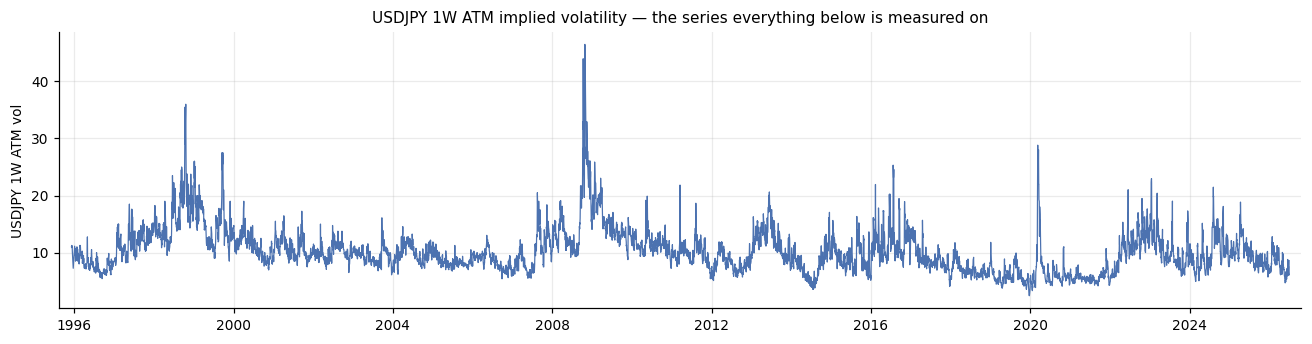

In [4]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9})

C_BETA, C_MI = "#4c72b0", "#55a868"      # one hue per measure, held fixed everywhere below
C_SIG, C_SIG_MI = "#c44e52", "#8172b2"   # significance markers, distinct from the curve hue
C_MUTE = "#adb5bd"

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(panel.index, panel["atm_vol"], color=C_BETA, lw=0.8)
ax.set_ylabel(f"{PAIR} {TENOR} ATM vol")
ax.set_title(f"{PAIR} {TENOR} ATM implied volatility — the series everything below is measured on",
             fontsize=10)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()

## 3. Selecting event types by Bloomberg **relevance**

Rather than testing every release on the calendar and leaning on multiple-testing correction
to sort it out afterwards, the candidate set is chosen up front using Bloomberg's own
`relevance` score — the share of terminal users who set an alert on that release. It is a
measure of *attention*, decided by the market and not by this notebook, and it is available
before any vol data is touched, so using it costs nothing in selection bias.

**The scale is inspected before the cutoff is applied**, not assumed. The cell prints the
distribution first. Two filters, intersected:

- `relevance >= RELEVANCE_CUTOFF`
- at least `MIN_OCCURRENCES` raw calendar occurrences (a first pass; the binding version of
  this threshold is re-applied to *clean episodes* after windowing, in step 4b)

The resulting list is printed immediately and in full. **This is the first thing worth
eyeballing.** NFP, US CPI, FOMC, Japan CPI and the BOJ decision should all be present;
minor regional prints should not. If the list looks wrong, nothing downstream is
trustworthy and the cutoff needs changing before anything else is read.

[2026-08-05 22:35:08] INFO  stage start: 3. event selection
Relevance scale as it actually appears in this file (USD + JPY rows):
count   16880.00
mean       91.09
std         5.30
min        80.00
25%        86.80
50%        90.10
75%        96.00
max        99.30

50 distinct USD/JPY event types. Count surviving each candidate cutoff (intersected with n_raw >= 30):
   relevance >= 80:  50 event types
   relevance >= 85:  39 event types
   relevance >= 88:  30 event types
   relevance >= 90:  25 event types   <-- chosen
   relevance >= 92:  19 event types
   relevance >= 95:  11 event types
   relevance >= 97:   6 event types


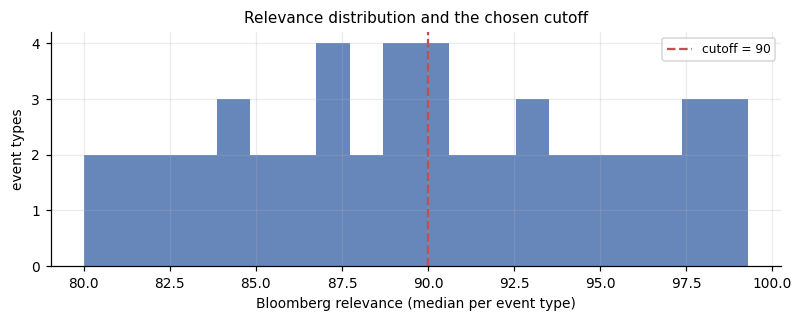


SELECTED EVENT TYPES  (25, relevance >= 90, n_raw >= 30)
ccy                            event  relevance  n_raw      first       last
JPY                  BOJ Target Rate       98.9    221 2006-08-11 2026-06-16
JPY        Industrial Production MoM       97.8    612 2000-04-18 2026-06-30
JPY                     Jobless Rate       96.7    318 2000-02-28 2026-06-30
JPY                     Natl CPI YoY       95.6    298 2001-09-28 2026-06-19
JPY            GDP Annualized SA QoQ       94.4    174 2004-12-07 2026-06-08
JPY                       GDP SA QoQ       93.3    174 2004-12-07 2026-06-08
JPY                          PPI YoY       92.2    273 2003-10-14 2026-06-10
JPY      Tokyo CPI Ex-Fresh Food YoY       91.1    298 2001-09-28 2026-06-26
JPY      BoP Current Account Balance       90.0    354 1997-01-13 2026-06-08
JPY         S&P Global Japan PMI Mfg       90.0    382 2006-11-29 2026-07-01
USD       Change in Nonfarm Payrolls       99.3    354 1997-01-10 2026-06-05
USD           Init

In [5]:
selected_events = []

with stage("3. event selection", fatal=True):
    rel_by_type = (events.groupby(["ccy", "event"])
                   .agg(n_raw=("event", "size"),
                        relevance=("relevance", "median"),
                        first=("date", "min"), last=("date", "max"))
                   .reset_index())

    print("Relevance scale as it actually appears in this file (USD + JPY rows):")
    print(events["relevance"].describe().to_string(float_format=lambda x: f"{x:8.2f}"))
    print(f"\n{len(rel_by_type)} distinct {'/'.join(EVENT_CCYS)} event types. "
          "Count surviving each candidate cutoff (intersected with "
          f"n_raw >= {MIN_OCCURRENCES}):")
    for cut in [80, 85, 88, 90, 92, 95, 97]:
        k = int(((rel_by_type["relevance"] >= cut) & (rel_by_type["n_raw"] >= MIN_OCCURRENCES)).sum())
        mark = "   <-- chosen" if cut == RELEVANCE_CUTOFF else ""
        print(f"   relevance >= {cut:>2}: {k:>3} event types{mark}")

    fig, ax = plt.subplots(figsize=(7.5, 3.0))
    ax.hist(rel_by_type["relevance"], bins=20, color=C_BETA, alpha=0.85)
    ax.axvline(RELEVANCE_CUTOFF, color=C_SIG, ls="--", lw=1.5,
               label=f"cutoff = {RELEVANCE_CUTOFF:g}")
    ax.set_xlabel("Bloomberg relevance (median per event type)")
    ax.set_ylabel("event types")
    ax.set_title("Relevance distribution and the chosen cutoff", fontsize=10)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    chosen = rel_by_type[(rel_by_type["relevance"] >= RELEVANCE_CUTOFF)
                         & (rel_by_type["n_raw"] >= MIN_OCCURRENCES)].copy()
    chosen = chosen.sort_values(["ccy", "relevance"], ascending=[True, False])
    selected_events = [(r.ccy, r.event) for r in chosen.itertuples()]

    if not 10 <= len(selected_events) <= 40:
        log(f"selected {len(selected_events)} event types -- outside the intended 15-25 band. "
            "The relevance cutoff probably needs adjusting.", "WARN")

    print("\n" + "=" * 88)
    print(f"SELECTED EVENT TYPES  ({len(selected_events)}, relevance >= {RELEVANCE_CUTOFF:g}, "
          f"n_raw >= {MIN_OCCURRENCES})")
    print("=" * 88)
    print(chosen[["ccy", "event", "relevance", "n_raw", "first", "last"]]
          .to_string(index=False, formatters={"first": lambda d: f"{d:%Y-%m-%d}",
                                              "last": lambda d: f"{d:%Y-%m-%d}"}))
    print("=" * 88)
    log(f"selected {len(selected_events)} event types at relevance >= {RELEVANCE_CUTOFF}")

## 4. Episodes, anchoring, and a light de-dup

**Anchoring.** Each historical occurrence becomes one **episode**: an anchor day (`k = 0`)
plus the ten trading days around it. A release is mapped to the **next available trading
day** in the USDJPY panel via `map_to_next_trading_day`, reused from the reference notebook
— a Sunday-night Tokyo print is priced on Monday, so Monday is where it anchors. Getting
this roll wrong is how look-ahead effects get manufactured.

**Completeness.** An episode whose `[-5, +5]` window runs off the edge of history or across
a data gap is dropped. If incomplete episodes were kept, `k = -5` and `k = +5` would be
estimated on a systematically different subset than `k = 0`, and the *shape* of the curve
would partly reflect which episodes happened to be complete at each end.

**De-dup — one short cell.** `CPI MoM` and `CPI YoY` are the same release printed twice, so
they carry identical calendar dates and would enter as two near-identical event types. They
are collapsed on **calendar overlap**,

$$\mathrm{overlap}(A,B) = \frac{|D_A \cap D_B|}{\min(|D_A|,|D_B|)} \ge 0.90,$$

keeping the member with the longer usable history. Correlating `surprise_z` — the reference
notebooks' original method — is unavailable here by design, and correlating two 0/1 calendar
indicators is not the same test. The reference notebook argues this at length; with ~25
candidates rather than ~270 the short version is enough.

`MIN_OCCURRENCES` is then re-applied to **clean episode counts**, not raw calendar hits, so
an event type with 400 calendar dates but only 12 windows inside the vol history cannot slip
through looking well-powered.

In [6]:
def map_to_next_trading_day(event_dates, trading_dates):
    """Roll each event date onto the first trading day at or after it. Reused from
    usd_event_time_iv_template.ipynb. Events past the panel's end map to NaT."""
    trading_dates = np.asarray(trading_dates)
    idx = np.searchsorted(trading_dates, event_dates, side="left")
    out = np.full(len(event_dates), np.datetime64("NaT"), dtype="datetime64[ns]")
    ok = idx < len(trading_dates)
    out[ok] = trading_dates[idx[ok]]
    return out


def clean_anchor_positions(ccy, event_name):
    """Window-complete, de-duplicated anchor positions for one event type."""
    ev_dates = np.sort(events.loc[(events["ccy"] == ccy) & (events["event"] == event_name),
                                  "date"].unique())
    if len(ev_dates) == 0:
        return np.array([], dtype=int)
    mapped = map_to_next_trading_day(ev_dates, PANEL_DATES)
    mapped = mapped[~pd.isna(mapped)]
    pos = np.unique(np.searchsorted(PANEL_DATES, mapped))
    pos = pos[pos < N_PANEL]
    return pos[complete_mask[pos]]


episodes_raw = {}
with stage("4a. episodes", fatal=True):
    for ccy, name in selected_events:
        episodes_raw[(ccy, name)] = clean_anchor_positions(ccy, name)
    log("clean-episode counts computed for all selected event types")


def calendar_overlap(a, b):
    if len(a) == 0 or len(b) == 0:
        return 0.0
    return len(np.intersect1d(a, b)) / min(len(a), len(b))


episodes = {}
merge_log = []
with stage("4b. de-dup + MIN_OCCURRENCES", fatal=True):
    # rank fixed BEFORE any results are seen: most clean episodes, then longest span,
    # then alphabetical. Never outcome-based.
    def rank_key(k):
        pos = episodes_raw[k]
        span = int(pos.max() - pos.min()) if len(pos) > 1 else 0
        return (len(pos), span, [-ord(c) for c in k[1]])

    for ccy in EVENT_CCYS:
        names = sorted([k for k in episodes_raw if k[0] == ccy], key=rank_key, reverse=True)
        kept = []
        for k in names:
            dup_of = next((r for r in kept
                           if calendar_overlap(episodes_raw[k], episodes_raw[r]) >= OVERLAP_THRESHOLD),
                          None)
            if dup_of is None:
                kept.append(k)
            else:
                merge_log.append({"dropped": f"{k[0]} {k[1]}", "kept": f"{dup_of[0]} {dup_of[1]}",
                                  "overlap": round(calendar_overlap(episodes_raw[k],
                                                                    episodes_raw[dup_of]), 3)})
        for k in kept:
            episodes[k] = episodes_raw[k]

    print(f"De-dup at overlap >= {OVERLAP_THRESHOLD}: "
          f"{len(episodes_raw)} -> {len(episodes)} event types.")
    if merge_log:
        print(pd.DataFrame(merge_log).to_string(index=False))
    else:
        print("(no same-release families detected at this threshold)")

    funnel = pd.DataFrame([{"ccy": c, "event": e,
                            "n_raw_calendar": int(((events["ccy"] == c) &
                                                   (events["event"] == e)).sum()),
                            "n_clean_episodes": len(episodes_raw[(c, e)]),
                            "kept_after_dedup": (c, e) in episodes,
                            "passes_min_occ": len(episodes_raw[(c, e)]) >= MIN_OCCURRENCES}
                           for (c, e) in selected_events])

    EVENT_KEYS = sorted([k for k, v in episodes.items() if len(v) >= MIN_OCCURRENCES])
    dropped_small = [k for k, v in episodes.items() if len(v) < MIN_OCCURRENCES]
    for k in dropped_small:
        SKIPPED_EVENTS[k] = f"only {len(episodes[k])} clean episodes (< {MIN_OCCURRENCES})"

    print(f"\nMIN_OCCURRENCES = {MIN_OCCURRENCES} on CLEAN episodes: "
          f"{len(episodes)} -> {len(EVENT_KEYS)} event types.")
    if dropped_small:
        print("dropped for thin clean history:")
        for k in dropped_small:
            print(f"   {k[0]} {k[1]}: {len(episodes[k])} clean episodes")
    print("\nFunnel (raw calendar hits -> clean, window-complete episodes):")
    print(funnel.sort_values(["ccy", "n_clean_episodes"], ascending=[True, False])
          .to_string(index=False))
    log(f"{len(EVENT_KEYS)} event types carry forward into the regressions")

[2026-08-05 22:35:08] INFO  stage start: 4a. episodes
[2026-08-05 22:35:08] INFO  clean-episode counts computed for all selected event types
[2026-08-05 22:35:08] INFO  stage done : 4a. episodes (0.0s)
[2026-08-05 22:35:08] INFO  stage start: 4b. de-dup + MIN_OCCURRENCES
De-dup at overlap >= 0.9: 25 -> 23 event types.
       dropped                      kept  overlap
   USD CPI YoY               USD CPI MoM    0.996
JPY GDP SA QoQ JPY GDP Annualized SA QoQ    1.000

MIN_OCCURRENCES = 30 on CLEAN episodes: 23 -> 23 event types.

Funnel (raw calendar hits -> clean, window-complete episodes):
ccy                            event  n_raw_calendar  n_clean_episodes  kept_after_dedup  passes_min_occ
JPY        Industrial Production MoM             612               611              True            True
JPY         S&P Global Japan PMI Mfg             382               381              True            True
JPY      BoP Current Account Balance             354               353              True

### Design frames

One row-aligned frame per event type. Every regression, permutation and MI computation
below slices from these, so the sample is identical across steps 5–10 by construction.

`assign_relative_days` maps each trading day to `(episode index, relative day k)`, assigning
a day to its **nearest** anchor where an event's own windows overlap (weekly releases have
11-day windows and a 5-day cadence). Without that rule a single day could be `k = +3` of one
episode and `k = -4` of the next, and the day dummies would stop being mutually exclusive.

Clustering is by **episode**: all days of one release's window share a cluster, and every
non-event day is its own singleton cluster. This is what makes the standard errors robust to
the fact that the eleven days of a window are anything but independent draws.

In [7]:
def assign_relative_days(anchors, n=None):
    """Map each panel position to (episode index, relative day k) or (-1, nan).
    Days inside two of the same event's windows go to the NEAREST anchor, ties earlier."""
    n = N_PANEL if n is None else n
    ep = np.full(n, -1, dtype=int)
    rel = np.full(n, np.nan)
    best = np.full(n, np.inf)
    for j, a in enumerate(np.sort(anchors)):
        lo, hi = max(0, a - PRE_DAYS), min(n - 1, a + POST_DAYS)
        for i in range(lo, hi + 1):
            d = abs(i - a)
            if d < best[i]:
                best[i], ep[i], rel[i] = d, j, i - a
    return ep, rel


def episode_groups(ep):
    """Cluster id per panel row: episode index in-window, unique singleton otherwise."""
    g = np.empty(len(ep), dtype=int)
    n_ep = ep.max() + 1 if (ep >= 0).any() else 0
    g[ep >= 0] = ep[ep >= 0]
    solo = np.flatnonzero(ep < 0)
    g[solo] = n_ep + np.arange(len(solo))
    return g


def build_frame(key):
    anchors = episodes[key]
    ep, rel = assign_relative_days(anchors)
    rows = np.flatnonzero(USABLE)
    return {"key": key, "anchors": anchors, "rows": rows,
            "y": Y_ALL[rows], "lag1": LAG_ALL[rows],
            "rel": rel[rows], "groups": episode_groups(ep)[rows],
            "dates": PANEL_DATES[rows], "n_episodes": len(anchors)}


frames = {}
with stage("4c. design frames", fatal=True):
    for k in EVENT_KEYS:
        frames[k] = build_frame(k)
    _f = frames[EVENT_KEYS[0]]
    log(f"frames built: {len(frames)} event types, {len(_f['y'])} usable panel rows each")
    print(pd.DataFrame([{"ccy": k[0], "event": k[1], "n_episodes": frames[k]["n_episodes"],
                         "in_window_days": int((~np.isnan(frames[k]["rel"])).sum()),
                         "in_window_share": (~np.isnan(frames[k]["rel"])).mean()}
                        for k in EVENT_KEYS])
          .sort_values("n_episodes", ascending=False)
          .to_string(index=False, float_format=lambda x: f"{x:6.3f}"))

[2026-08-05 22:35:08] INFO  stage start: 4c. design frames
[2026-08-05 22:35:08] INFO  frames built: 23 event types, 7824 usable panel rows each
ccy                            event  n_episodes  in_window_days  in_window_share
USD           Initial Jobless Claims        1505            7481            0.956
USD        MBA Mortgage Applications        1155            5864            0.749
USD            U. of Mich. Sentiment         650            6547            0.837
JPY        Industrial Production MoM         611            6267            0.801
USD             Durable Goods Orders         470            4541            0.580
JPY         S&P Global Japan PMI Mfg         381            3540            0.452
JPY      BoP Current Account Balance         353            3883            0.496
USD                ISM Manufacturing         353            3883            0.496
USD  Conf. Board Consumer Confidence         352            3872            0.495
USD       Change in Nonfarm Payroll

## 5. Event vs. non-event screen — does this release move 1W vol at all?

One regression per event type:

$$\log \mathrm{IV}_t = \alpha + \beta\, D^{[-2,+2]}_t + \gamma \log \mathrm{IV}_{t-1} + \varepsilon_t$$

`D_window` covers the **event day ± 2 trading days**, deliberately narrower than the
reference notebook's `[-7, +5]` screen. The reason is that this is a *screen*, not the
shape: it should be aimed at the tightest region where an effect is most likely to be
concentrated, so the test is not diluted by six flat days at the edges of a wide window.
The full shape is what step 6 is for, and step 6 uses the wider `[-5, +5]`.

Standard errors are episode-clustered. The p-values get their own small BH-FDR correction
across the event types tested here — a separate family from the day-level grid in step 7,
because this screen decides *which* event types get decomposed and is answered before any
day-level test exists.

**A known blind spot of a single-window screen, visible in the output above.** The expected
shape of an event-vol pattern is a run-up into the release followed by a crush after it. A
single `[-2,+2]` dummy averages both halves together, so an event with a *clean, symmetric*
run-up-then-crush can screen out at approximately zero. US `CPI MoM` (beta = -0.0035,
q = 0.22) is the most likely instance here — its step-6 curve is not estimated at all because
of this. The reference notebook solves it by running a second, pre-event-only screen
(`[-7,-1]`) alongside the full window and passing an event type if *either* clears. That is
deliberately not done here — this notebook is specified to run one screen regression — so the
cost is stated instead of hidden: **an event type absent from the stack below is not
evidence that the release does nothing; it may be a release whose two halves cancelled.**

**This table stands on its own** as the direct answer to "does this event move USDJPY 1W
implied vol".

In [8]:
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests


def screen_fit(frame):
    rel = frame["rel"]
    D = ((~np.isnan(rel)) & (np.abs(rel) <= SCREEN_HALF_WIDTH)).astype(float)
    if D.std() == 0:
        raise ValueError("screen dummy has no variation")
    X = np.column_stack([np.ones(len(D)), D, frame["lag1"]])
    res = sm.OLS(frame["y"], X).fit(cov_type="cluster", cov_kwds={"groups": frame["groups"]})
    return {"beta": float(res.params[1]), "se": float(res.bse[1]),
            "t": float(res.tvalues[1]), "p": float(res.pvalues[1]),
            "ar1": float(res.params[2]), "n_treated": int(D.sum())}


screen = pd.DataFrame()
with stage("5. event-vs-non-event screen"):
    rows = []
    for k in EVENT_KEYS:
        try:
            r = screen_fit(frames[k])
        except Exception as exc:                      # one bad event type must not stop the rest
            SKIPPED_EVENTS[k] = f"screen regression failed: {type(exc).__name__}: {exc}"
            log(f"screen failed for {k[0]} {k[1]}: {type(exc).__name__}: {exc}", "ERROR")
            continue
        rows.append({"ccy": k[0], "event": k[1], "n_episodes": frames[k]["n_episodes"], **r})
    screen = pd.DataFrame(rows)

    if len(screen):
        _, q, _, _ = multipletests(screen["p"].values, alpha=FDR_ALPHA, method="fdr_bh")
        screen["q"] = q
        screen["significant"] = screen["q"] < FDR_ALPHA
        screen["effect_pct"] = np.exp(screen["beta"]) - 1
        screen = screen.sort_values("beta", ascending=False).reset_index(drop=True)

    print(f"Event vs non-event screen -- D = event day +/- {SCREEN_HALF_WIDTH} trading days, "
          f"BH-FDR at alpha={FDR_ALPHA} across {len(screen)} event types")
    print(screen[["ccy", "event", "n_episodes", "beta", "effect_pct", "se", "t", "p", "q",
                  "significant"]]
          .to_string(index=False, float_format=lambda x: f"{x:8.4f}"))

    STACK_KEYS = [(r.ccy, r.event) for r in screen.itertuples() if r.significant]
    for r in screen.itertuples():
        if not r.significant:
            SKIPPED_EVENTS[(r.ccy, r.event)] = f"failed event-vs-non-event screen (q={r.q:.3f})"
    log(f"screen: {len(STACK_KEYS)} of {len(screen)} event types pass and proceed to the stack")

[2026-08-05 22:35:09] INFO  stage start: 5. event-vs-non-event screen
Event vs non-event screen -- D = event day +/- 2 trading days, BH-FDR at alpha=0.05 across 23 event types
ccy                            event  n_episodes     beta  effect_pct       se        t        p        q  significant
JPY      Tokyo CPI Ex-Fresh Food YoY         297   0.0152      0.0153   0.0025   6.1390   0.0000   0.0000         True
JPY                     Jobless Rate         317   0.0107      0.0108   0.0023   4.6140   0.0000   0.0000         True
USD                ISM Manufacturing         353   0.0056      0.0056   0.0025   2.2766   0.0228   0.0525        False
USD  Conf. Board Consumer Confidence         352   0.0053      0.0053   0.0024   2.2147   0.0268   0.0560        False
USD               GDP Annualized QoQ         349   0.0053      0.0053   0.0025   2.1342   0.0328   0.0629        False
USD             Durable Goods Orders         470   0.0047      0.0047   0.0024   1.9747   0.0483   0.0855     

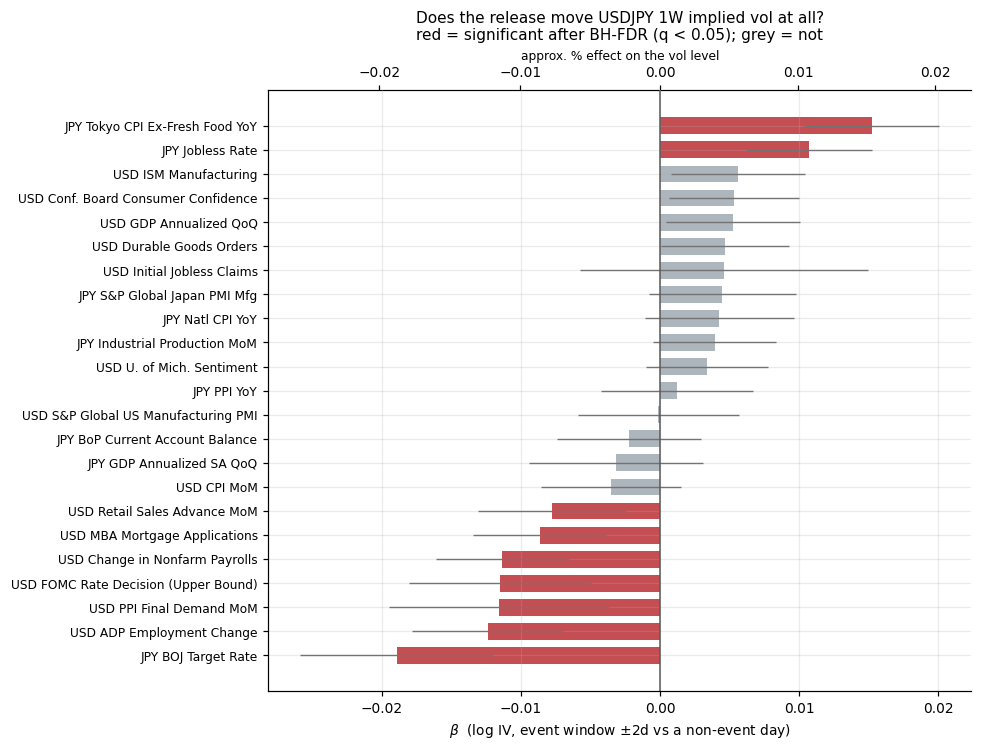

In [9]:
if len(screen):
    s = screen.sort_values("beta")
    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.30 * len(s))))
    cols = [C_SIG if sig else C_MUTE for sig in s["significant"]]
    ax.barh(np.arange(len(s)), s["beta"], xerr=CI_Z * s["se"],
            color=cols, error_kw={"lw": 0.9, "ecolor": "0.45"}, height=0.7)
    ax.set_yticks(np.arange(len(s)))
    ax.set_yticklabels([f"{r.ccy} {r.event[:38]}" for r in s.itertuples()], fontsize=8)
    ax.axvline(0, color="0.35", lw=1)
    ax.set_xlabel(r"$\beta$  (log IV, event window $\pm$2d vs a non-event day)")
    ax.set_title(f"Does the release move {PAIR} {TENOR} implied vol at all?\n"
                 f"red = significant after BH-FDR (q < {FDR_ALPHA}); grey = not", fontsize=10)
    sec = ax.secondary_xaxis("top", functions=(lambda v: np.exp(v) - 1, lambda v: np.log(v + 1)))
    sec.set_xlabel("approx. % effect on the vol level", fontsize=8)
    plt.tight_layout()
    plt.show()

## 6. The event-time stack — day dummies, relative days -5 to +5

$$\log \mathrm{IV}_t = \alpha + \sum_{k=-5}^{+5} \beta_k D_{k,t} + \gamma \log \mathrm{IV}_{t-1} + \varepsilon_t$$

**Why `[-5, +5]` and not the reference notebook's `[-7, +5]`.** That notebook models the
**1D** tenor, which reprices sharply and locally — an overnight quote can move on the
morning of the release and be back to normal two days later, so a wide window costs little
and catches a long run-up. A **1W** quote cannot do that. It always spans five trading days,
so any single day's news is smeared across the whole week the quote covers; its response is
slower to build and slower to decay, and its day-to-day increments are correspondingly
smaller and more autocorrelated. Eleven days is a better match to what a weekly-horizon
quote can actually resolve, and it also keeps the day-level grid at 11 tests per event
instead of 13 — which matters directly, since step 7 corrects across that grid flat.

**Reading β_k.** The reference category is **every trading day outside this event's window**.
So β_k is "log IV on relative day k versus an ordinary non-event day, holding yesterday's
log IV fixed". It is *not* day k versus day k−1, and *not* day k versus day −5. A template
where every β_k is positive is coherent — it says vol is elevated across the whole window.

`exp(β_k) − 1` is reported alongside, because "1W ATM sits about 2.4% above normal the day
before CPI" is the sentence someone can act on.

The permutation loop below refits this model tens of thousands of times, so a NumPy
clustered-OLS kernel replaces `statsmodels` there. The next cell asserts the two agree to
machine precision before anything relies on it — a speed-up is only legitimate if it is
provably the same estimator.

In [10]:
def cluster_ols(y, X, groups):
    """OLS with cluster-robust covariance; numerically identical to
    sm.OLS(...).fit(cov_type='cluster') -- asserted below before any use."""
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ (X.T @ y)
    resid = y - X @ beta
    u = X * resid[:, None]
    g_idx = np.unique(groups, return_inverse=True)[1]
    ug = np.zeros((g_idx.max() + 1, X.shape[1]))
    np.add.at(ug, g_idx, u)
    meat = ug.T @ ug
    G, k, N = ug.shape[0], X.shape[1], len(y)
    V = (G / (G - 1)) * ((N - 1) / (N - k)) * (XtX_inv @ meat @ XtX_inv)
    return beta, np.sqrt(np.diag(V))


def day_dummies(rel):
    return np.column_stack([(rel == k).astype(float) for k in STACK_KS])


def stack_design(rel, lag1):
    D = day_dummies(rel)
    live = D.sum(axis=0) > 0            # an empty k would make X singular
    X = np.column_stack([np.ones(D.shape[0]), D[:, live], lag1])
    return X, live


def stack_fit_sm(frame):
    """Reported fit, via statsmodels as specified."""
    X, live = stack_design(frame["rel"], frame["lag1"])
    res = sm.OLS(frame["y"], X).fit(cov_type="cluster", cov_kwds={"groups": frame["groups"]})
    beta = np.full(len(STACK_KS), np.nan); se = np.full(len(STACK_KS), np.nan)
    tval = np.full(len(STACK_KS), np.nan)
    beta[live] = res.params[1:1 + live.sum()]
    se[live]   = res.bse[1:1 + live.sum()]
    tval[live] = res.tvalues[1:1 + live.sum()]
    return {"beta": beta, "se": se, "t": tval, "live": live}


with stage("6a. validate fast clustered-OLS kernel", fatal=True):
    _vf = frames[STACK_KEYS[0] if STACK_KEYS else EVENT_KEYS[0]]
    _X, _live = stack_design(_vf["rel"], _vf["lag1"])
    _b, _se = cluster_ols(_vf["y"], _X, _vf["groups"])
    _sm = sm.OLS(_vf["y"], _X).fit(cov_type="cluster", cov_kwds={"groups": _vf["groups"]})
    _db = float(np.abs(_b - _sm.params).max())
    _dse = float(np.abs(_se / _sm.bse - 1).max())
    print(f"fast kernel vs statsmodels: max |dcoef| = {_db:.3e}, max relative |dSE| = {_dse:.3e}")
    if _db > 1e-8 or _dse > 1e-8:
        raise AssertionError("cluster_ols does not reproduce statsmodels -- refusing to use it.")
    print("-> identical estimator; safe inside the permutation loop.")


stack_fits = {}
with stage("6b. day-dummy stack fits"):
    for k in STACK_KEYS:
        try:
            stack_fits[k] = stack_fit_sm(frames[k])
        except Exception as exc:
            SKIPPED_EVENTS[k] = f"stack regression failed: {type(exc).__name__}: {exc}"
            log(f"stack fit failed for {k[0]} {k[1]}: {type(exc).__name__}: {exc}", "ERROR")
    STACK_KEYS = [k for k in STACK_KEYS if k in stack_fits]
    log(f"stack fitted for {len(stack_fits)} event types")

[2026-08-05 22:35:10] INFO  stage start: 6a. validate fast clustered-OLS kernel
fast kernel vs statsmodels: max |dcoef| = 9.261e-14, max relative |dSE| = 2.720e-13
-> identical estimator; safe inside the permutation loop.
[2026-08-05 22:35:10] INFO  stage done : 6a. validate fast clustered-OLS kernel (0.0s)
[2026-08-05 22:35:10] INFO  stage start: 6b. day-dummy stack fits


[2026-08-05 22:35:10] INFO  stack fitted for 9 event types
[2026-08-05 22:35:10] INFO  stage done : 6b. day-dummy stack fits (0.0s)


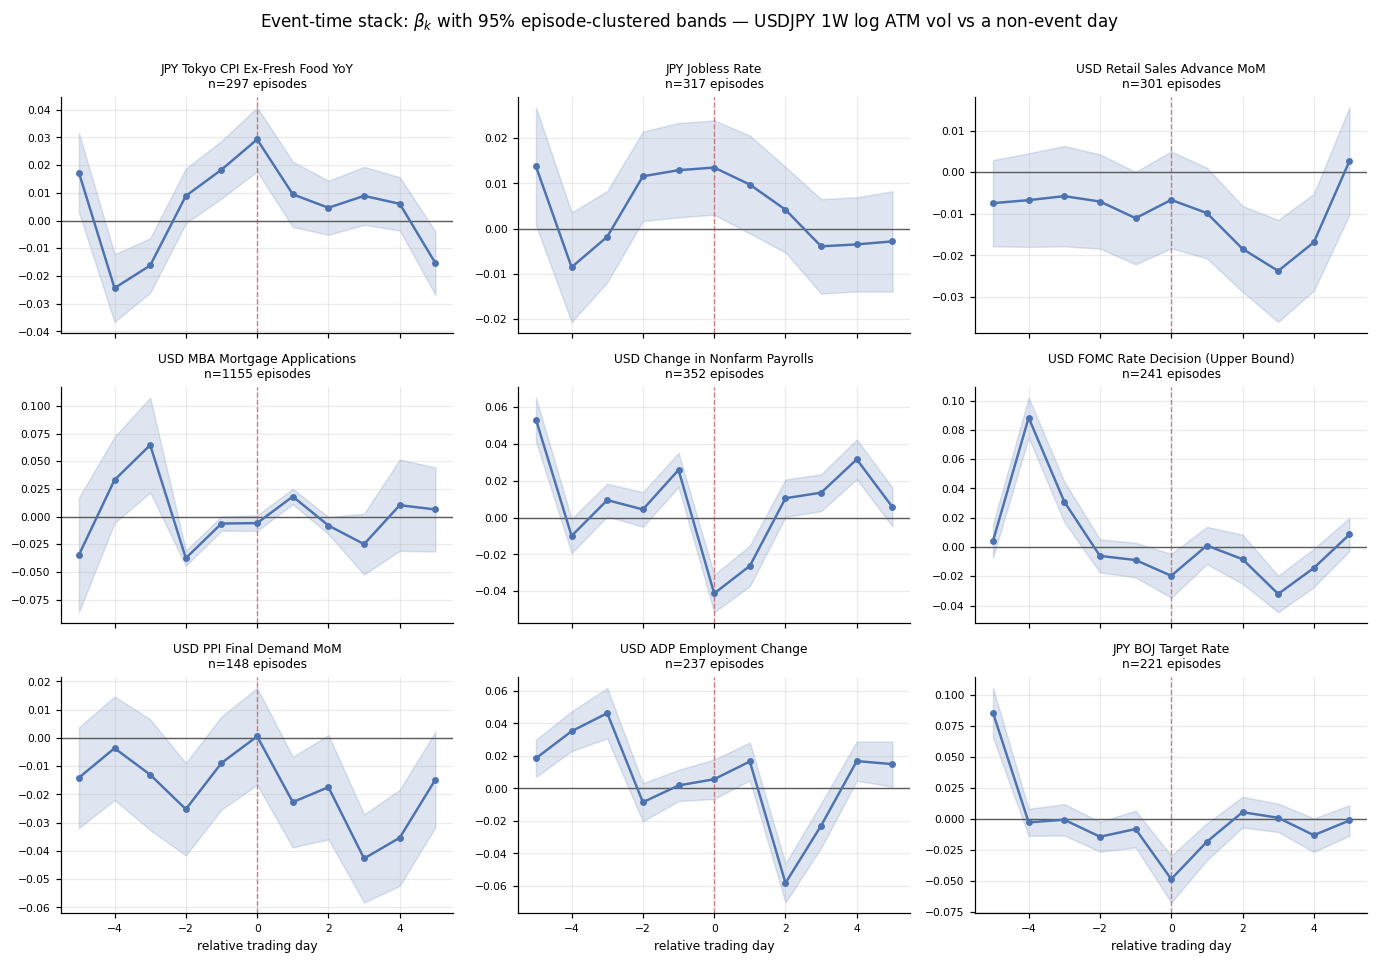

In [11]:
# beta_k curves for EVERY event type reaching this step -- no top-N cutoff.
if stack_fits:
    keys = STACK_KEYS
    ncol = 3
    nrow = int(np.ceil(len(keys) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 2.9 * nrow), sharex=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, key in zip(axes, keys):
        f = stack_fits[key]
        b, se = f["beta"], f["se"]
        ax.axhline(0, color="0.35", lw=0.9)
        ax.axvline(0, color=C_SIG, lw=0.9, ls="--", alpha=0.7)
        ax.fill_between(STACK_KS, b - CI_Z * se, b + CI_Z * se, color=C_BETA, alpha=0.18)
        ax.plot(STACK_KS, b, color=C_BETA, lw=1.6, marker="o", ms=3.5)
        ax.set_title(f"{key[0]} {key[1][:34]}\nn={frames[key]['n_episodes']} episodes", fontsize=8)
        ax.tick_params(labelsize=7)
    for ax in axes[len(keys):]:
        ax.axis("off")
    for ax in axes[max(0, len(axes) - ncol):]:
        ax.set_xlabel("relative trading day", fontsize=8)
    fig.suptitle(rf"Event-time stack: $\beta_k$ with 95% episode-clustered bands — "
                 rf"{PAIR} {TENOR} log ATM vol vs a non-event day", fontsize=11, y=1.0)
    plt.tight_layout()
    plt.show()

## 7. Calendar-matched permutation test

Every p-value from here on comes from refitting the **identical** stack model on **placebo
release dates** and asking how often the placebo produces something as extreme as the real
thing.

**Why the placebos must match the calendar's structure.** Drawing placebo dates uniformly
at random would make the null far too easy to beat. Real releases land on weekdays, usually
a *characteristic* weekday (US claims are Thursdays; NFP is a Friday), and FX implied vol
has day-of-week structure of its own. A uniform placebo would scatter a Friday event's fakes
across the week, so the real event would beat the null partly by *being on Fridays*.

`make_placebo_sets` matches three things:

1. **Same number of episodes** as the real event.
2. **Same weekday distribution** — 180 real Fridays and 20 Thursdays means every placebo
   set draws exactly 180 Fridays and 20 Thursdays.
3. **Holidays avoided by construction** — candidates are drawn only from window-complete
   positions in USDJPY's *own* trading calendar. A day the pair did not trade cannot be
   selected, and neither can a day whose window straddles a gap. Stronger than matching an
   external holiday list.

Non-overlap between placebo windows is enforced *unless the real event's own windows
overlap* (weekly claims and mortgage applications, at a 5-day cadence, cannot avoid it).
Forcing tidier placebos than the real data for those releases would bias the test toward
significance.

**One flat BH-FDR** across the whole `(event, relative_day)` grid of β_k p-values — no
tiering. The reference notebook's three-tier hierarchy exists because it screens ~270
candidate event types, where a flat correction over thousands of day-level tests would
swamp the unit-level decisions that gate them. Here the candidate set is already small and
pre-filtered on relevance and on the step-5 screen, so a single flat correction over roughly
`~25 × 11` cells is both simpler and adequately conservative.

In [12]:
def make_placebo_sets(key, n_perm, seed):
    """`n_perm` placebo anchor sets matching episode count, weekday mix, and USDJPY's own
    window-complete calendar."""
    real = np.sort(episodes[key])
    wd_needed = pd.Series(WEEKDAY[real]).value_counts().to_dict()
    cand_by_wd = {w: np.flatnonzero(complete_mask & (WEEKDAY == w)) for w in wd_needed}
    for w, need in wd_needed.items():
        if len(cand_by_wd[w]) < need:
            raise ValueError(f"only {len(cand_by_wd[w])} candidate days on weekday {w}, "
                             f"need {need}")
    # scarcest weekday first: satisfy the tightest constraint while the field is open
    order = sorted(wd_needed, key=lambda w: len(cand_by_wd[w]) / max(wd_needed[w], 1))

    span = PRE_DAYS + POST_DAYS
    real_self_overlap = bool(len(real) > 1 and np.any(np.diff(real) <= span))
    enforce_gap = not real_self_overlap

    rng = np.random.default_rng(seed)
    sets, n_relaxed = [], 0
    for _ in range(n_perm):
        blocked = np.zeros(N_PANEL, dtype=bool)
        chosen, relaxed = [], False
        for w in order:
            need = wd_needed[w]
            pool = rng.permutation(cand_by_wd[w])
            got = 0
            for p in pool:
                if got >= need:
                    break
                if enforce_gap and blocked[max(0, p - span):p + span + 1].any():
                    continue
                chosen.append(p); blocked[p] = True; got += 1
            if got < need:                     # infeasible -> fill without the gap constraint
                relaxed = True
                for p in [q for q in pool if not blocked[q]][:need - got]:
                    chosen.append(p); blocked[p] = True
        n_relaxed += int(relaxed)
        sets.append(np.sort(np.array(chosen, dtype=int)))
    return sets, {"real_self_overlap": real_self_overlap, "n_relaxed": n_relaxed}


def permutation_p(real, null, two_sided=False):
    """(1 + #{null at least as extreme}) / (1 + n). Never exactly zero -- a finite number
    of draws cannot supply infinite evidence."""
    null = np.asarray(null)
    null = null[~np.isnan(null)]
    if len(null) == 0 or np.isnan(real):
        return np.nan
    hits = int((np.abs(null) >= abs(real)).sum()) if two_sided else int((null >= real).sum())
    return (1 + hits) / (1 + len(null))


def stable_offset(key):
    """Deterministic per-event seed offset, stable across kernel restarts (hash() is not)."""
    return int(pd.util.hash_array(np.array([f"{key[0]}|{key[1]}"], dtype=object))[0] % 100000)


MIN_PERM_P = 1.0 / (N_PERMUTATIONS + 1)

with stage("7a. placebo generator demo", fatal=True):
    _dk = STACK_KEYS[0]
    _ps, _pinfo = make_placebo_sets(_dk, 3, PERM_SEED + stable_offset(_dk))
    _rw = pd.Series(WEEKDAY[np.sort(episodes[_dk])]).value_counts().sort_index().to_dict()
    _pw = pd.Series(WEEKDAY[_ps[0]]).value_counts().sort_index().to_dict()
    print(f"Placebo demo -- {_dk[0]} {_dk[1]}: real n_episodes = {len(episodes[_dk])}, "
          f"placebo sizes = {[len(s) for s in _ps]}")
    print(f"  real weekday mix    : {_rw}")
    print(f"  placebo weekday mix : {_pw}    (matched by construction)")
    print(f"  real windows self-overlap: {_pinfo['real_self_overlap']} "
          f"-> non-overlap constraint {'relaxed' if _pinfo['real_self_overlap'] else 'enforced'}")
    print(f"  permutation p floor: 1/{N_PERMUTATIONS + 1} = {MIN_PERM_P:.5f}")

[2026-08-05 22:35:10] INFO  stage start: 7a. placebo generator demo
Placebo demo -- JPY Tokyo CPI Ex-Fresh Food YoY: real n_episodes = 297, placebo sizes = [297, 297, 297]
  real weekday mix    : {0: 12, 1: 9, 3: 115, 4: 161}
  placebo weekday mix : {0: 12, 1: 9, 3: 115, 4: 161}    (matched by construction)
  real windows self-overlap: False -> non-overlap constraint enforced
  permutation p floor: 1/201 = 0.00498
[2026-08-05 22:35:10] INFO  stage done : 7a. placebo generator demo (0.0s)


## 8. TDMI — mutual information per relative day

Same day-dummy structure, a completely different instrument.

**Why it is not redundant with β_k.** β_k can only detect a **mean shift**. All of the
following are real event effects it reports as approximately zero:

- **Bimodality** — a BOJ meeting where a third of the time the decision genuinely surprises
  and vol jumps, and two-thirds of the time it is fully telegraphed and vol does nothing.
  The average across occurrences can sit right on top of a normal day.
- **Variance widening with no mean shift** — sometimes sharply up, sometimes sharply down,
  cancelling in the mean.
- **Skew** — usually slightly below normal, occasionally far above it.

Mutual information registers **any** dependence between the day dummy and vol, with no
functional-form assumption, so it catches all three.

**What MI is computed against.** Not the raw level. `mutual_info_regression(D_k, log_IV)` on
the raw series was tried in the reference notebook and returned zero significant days out of
1,300 — because β_k is estimated *net of* the AR(1) lag while MI on the raw level is net of
nothing, so MI mostly measured vol's own persistence, which is present identically in the
weekday-matched placebos and therefore cancels. So MI here is computed on log IV
**residualised on exactly what the regression conditions on** — a constant and
`log_atm_vol_lag1`, and nothing else. The day dummies are not residualised out; they are the
thing being tested.

**The same placebo sets as step 7**, reused draw for draw, so the two methods are directly
comparable rather than being tested against two different nulls.

**Prevalence-pooled null.** Two relative days with the same number of treated observations
have exchangeable null MI distributions — same dummy prevalence, same placebo sets — so
their null draws are pooled. This matters concretely: a per-day null gives 200 draws and a
p-value floor of 0.005, and BH over ~200 cells would then need ~20 cells tied at the floor
before it could reject anything, which risks reporting "no significant MI" *by construction*
rather than because the data said so. Pooling lifts the effective draw count roughly
eleven-fold and removes that artefact.

The two grids are FDR-corrected **separately** — one BH run over the β_k p-values, another
over the MI p-values — because step 9 compares their verdicts, which only means something if
each was corrected on its own terms.

In [13]:
from sklearn.feature_selection import mutual_info_regression


def mi_target(frame):
    """log IV with the SAME nuisance structure removed that the regression conditions on:
    a constant and the AR(1) lag. Not the day dummies -- those are what is being tested."""
    X = np.column_stack([np.ones(len(frame["y"])), frame["lag1"]])
    b, *_ = np.linalg.lstsq(X, frame["y"], rcond=None)
    return frame["y"] - X @ b


def mi_by_relative_day(rel, target):
    out = np.full(len(STACK_KS), np.nan)
    for j, k in enumerate(STACK_KS):
        D_k = (rel == k).astype(float)
        if D_k.sum() == 0:
            continue
        out[j] = mutual_info_regression(D_k.reshape(-1, 1), target,
                                        n_neighbors=MI_NEIGHBORS,
                                        random_state=MI_RANDOM_STATE)[0]
    return out


def mi_permutation_pvalues(frame, real, null):
    """One-sided upper p per relative day against the PREVALENCE-MATCHED pooled null."""
    counts = np.array([int((frame["rel"] == k).sum()) for k in STACK_KS])
    groups = {}
    for j, c in enumerate(counts):
        groups.setdefault(c, []).append(j)
    out = np.full(len(STACK_KS), np.nan)
    draws = np.zeros(len(STACK_KS), dtype=int)
    for j in range(len(STACK_KS)):
        ref = null[:, groups[counts[j]]]
        ref = ref[~np.isnan(ref)].ravel()
        draws[j] = len(ref)
        out[j] = permutation_p(real[j], ref)
    return out, draws


def run_permutation_batch(key, n_perm=N_PERMUTATIONS):
    """Full permutation batch for ONE event type: beta null + MI null on the SAME
    placebo sets. Returns everything needed to write a checkpoint."""
    frame = frames[key]
    sets, info = make_placebo_sets(key, n_perm, PERM_SEED + stable_offset(key))
    tgt = mi_target(frame)                       # independent of placebo dates -> once per event
    mi_real = mi_by_relative_day(frame["rel"], tgt)

    beta_null = np.full((n_perm, len(STACK_KS)), np.nan)
    mi_null   = np.full((n_perm, len(STACK_KS)), np.nan)
    rows = frame["rows"]
    for i, anchors in enumerate(sets):
        ep, rel_full = assign_relative_days(anchors)
        rel = rel_full[rows]
        X, live = stack_design(rel, frame["lag1"])
        groups = episode_groups(ep)[rows]
        try:
            b, _ = cluster_ols(frame["y"], X, groups)
            beta_null[i, live] = b[1:1 + live.sum()]
        except np.linalg.LinAlgError:
            pass                                  # singular placebo design -> leave NaN
        mi_null[i] = mi_by_relative_day(rel, tgt)
    return {"mi_real": mi_real, "beta_null": beta_null, "mi_null": mi_null, "info": info}


def checkpoint_path(key):
    slug = re.sub(r"[^A-Za-z0-9]+", "_", f"{key[0]}__{key[1]}")[:110]
    return os.path.join(CHECKPOINT_DIR, f"{PAIR}_{TENOR}__{slug}__n{N_PERMUTATIONS}.npz")


def save_checkpoint(key, r):
    tmp = checkpoint_path(key) + ".tmp.npz"       # write-then-rename: never a half-written file
    np.savez_compressed(tmp, mi_real=r["mi_real"], beta_null=r["beta_null"],
                        mi_null=r["mi_null"],
                        real_self_overlap=bool(r["info"]["real_self_overlap"]),
                        n_relaxed=int(r["info"]["n_relaxed"]))
    os.replace(tmp, checkpoint_path(key))


def load_checkpoint(key):
    p = checkpoint_path(key)
    if FORCE_RECOMPUTE or not os.path.isfile(p):
        return None
    try:
        z = np.load(p, allow_pickle=False)
        r = {"mi_real": z["mi_real"], "beta_null": z["beta_null"], "mi_null": z["mi_null"],
             "info": {"real_self_overlap": bool(z["real_self_overlap"]),
                      "n_relaxed": int(z["n_relaxed"])}}
        if r["beta_null"].shape != (N_PERMUTATIONS, len(STACK_KS)):
            log(f"checkpoint for {key} has wrong shape {r['beta_null'].shape} -- recomputing.",
                "WARN")
            return None
        return r
    except Exception as exc:                      # corrupt/partial -> recompute, never trust
        log(f"unreadable checkpoint for {key} ({exc}) -- recomputing.", "WARN")
        return None

### Pilot — at the FULL permutation count, then sanity-checked before the grid runs

The pilot runs `PILOT_N_EVENTS` event types through the **identical** code path at the
**full** `N_PERMUTATIONS = 200`. Not a reduced count: a short pilot exercises different array
shapes and different p-value floors than the real run, and can therefore pass while the real
run is broken — which is exactly how a prior notebook in this project got through a pilot and
still needed a full rerun. The pilot results are written to the same checkpoints, so nothing
is recomputed afterwards.

**Timing.** Elapsed time is extrapolated to the full event list. If the estimate exceeds
~45 minutes the notebook prints a loud warning **and proceeds anyway** — nobody is present
to approve an override, and silently dropping `N_PERMUTATIONS` to hit a time budget would
change every p-value floor in the notebook without saying so. If the count is ever reduced,
that decision gets logged prominently, not applied quietly.

**Two sanity checks before the full grid is allowed to start:**

1. **Non-degenerate MI.** At least one pilot event must show at least one relative day with
   a raw MI permutation p below `FDR_ALPHA`. An all-`False` MI result across every pilot
   event means the MI half is broken (wrong target, wrong null, wrong dummy alignment), not
   that the market is quiet — and it is the failure that cost a full rerun before.
2. **The p-value distribution is not pinned at the floor.** If nearly every p-value sits at
   exactly `1/(N+1)`, or every p-value is identical, the null is not varying and the test is
   vacuous.

If either check fails: **STOP**. The full grid does not run, a diagnostic is written to
`_run_log.txt` and a run summary explaining the stop is written to `_run_summary.txt`, and
the notebook raises. That is the intended overnight behaviour — a loud stop with a written
explanation beats eight hours of computing numbers that were never going to mean anything.

In [14]:
PILOT_OK = False
pilot_results = {}

with stage("8a. pilot at full N_PERMUTATIONS", fatal=True):
    pilot_keys = sorted(STACK_KEYS, key=lambda k: -frames[k]["n_episodes"])[:PILOT_N_EVENTS]
    log(f"pilot on {len(pilot_keys)} event types at FULL N_PERMUTATIONS={N_PERMUTATIONS}: "
        + ", ".join(f"{c} {e}" for c, e in pilot_keys))

    t0 = time.time()
    for k in pilot_keys:
        cached = load_checkpoint(k)
        if cached is not None:
            pilot_results[k] = cached
            log(f"pilot {k[0]} {k[1]}: loaded from checkpoint")
        else:
            pilot_results[k] = run_permutation_batch(k)
            save_checkpoint(k, pilot_results[k])
    pilot_secs = time.time() - t0

    per_event = pilot_secs / max(len(pilot_keys), 1)
    est_total = per_event * len(STACK_KEYS)
    print(f"\nPilot: {len(pilot_keys)} event types, N_PERMUTATIONS={N_PERMUTATIONS}, "
          f"{pilot_secs:.1f}s elapsed ({per_event:.1f}s per event type)")
    print(f"Extrapolated full grid over {len(STACK_KEYS)} event types: "
          f"{est_total/60:.1f} minutes")
    if est_total > PILOT_WARN_SECONDS:
        print("!" * 92)
        print(f"WARNING: estimated runtime {est_total/60:.0f} min exceeds the "
              f"{PILOT_WARN_SECONDS/60:.0f} min guideline.")
        print(f"PROCEEDING ANYWAY at N_PERMUTATIONS={N_PERMUTATIONS}. Nobody is present to "
              "approve an override, and")
        print("reducing the permutation count would move every p-value floor in the notebook. "
              "Per-event")
        print("checkpoints mean an interrupted run loses at most one event type.")
        print("!" * 92)
        log(f"RUNTIME WARNING: extrapolated {est_total/60:.0f} min > "
            f"{PILOT_WARN_SECONDS/60:.0f} min guideline; proceeding at full "
            f"N_PERMUTATIONS={N_PERMUTATIONS} without reduction.", "WARN")

    # ---------------- sanity checks ----------------
    diag = []
    mi_p_all, beta_p_all = [], []
    for k in pilot_keys:
        r = pilot_results[k]
        f = frames[k]
        mp, draws = mi_permutation_pvalues(f, r["mi_real"], r["mi_null"])
        bp = np.array([permutation_p(stack_fits[k]["beta"][j], r["beta_null"][:, j], True)
                       for j in range(len(STACK_KS))])
        mi_p_all.append(mp); beta_p_all.append(bp)
        diag.append({"ccy": k[0], "event": k[1][:34], "n_ep": f["n_episodes"],
                     "min_p_beta": np.nanmin(bp), "min_p_mi": np.nanmin(mp),
                     "n_mi_p<alpha": int(np.nansum(mp < FDR_ALPHA)),
                     "mi_null_draws": int(draws.min()),
                     "beta_null_sd": float(np.nanstd(r["beta_null"]))})
    print("\nPilot diagnostics (raw permutation p-values, before any FDR):")
    print(pd.DataFrame(diag).to_string(index=False, float_format=lambda x: f"{x:8.4f}"))

    mi_p_all = np.concatenate(mi_p_all); beta_p_all = np.concatenate(beta_p_all)
    mi_floor = 1.0 / (len(pilot_results[pilot_keys[0]]["mi_null"]) * len(STACK_KS) + 1)

    check_mi_alive = bool(np.nansum(mi_p_all < FDR_ALPHA) > 0)
    frac_beta_floor = float(np.nanmean(np.isclose(beta_p_all, MIN_PERM_P)))
    check_not_pinned = (frac_beta_floor < 0.90) and (np.nanstd(mi_p_all) > 0)

    print(f"\n  check 1  non-degenerate MI (some day with raw p < {FDR_ALPHA}): "
          f"{'PASS' if check_mi_alive else 'FAIL'} "
          f"({int(np.nansum(mi_p_all < FDR_ALPHA))} of {len(mi_p_all)} pilot MI cells)")
    print(f"  check 2  p-values not pinned at the floor: "
          f"{'PASS' if check_not_pinned else 'FAIL'} "
          f"({frac_beta_floor:.1%} of pilot beta p-values sit exactly at "
          f"{MIN_PERM_P:.5f}; MI p sd = {np.nanstd(mi_p_all):.4f})")

    PILOT_OK = check_mi_alive and check_not_pinned
    if not PILOT_OK:
        msg = (
            "PILOT SANITY CHECK FAILED -- full permutation grid NOT run.\n"
            f"  check 1 (non-degenerate MI)        : {'PASS' if check_mi_alive else 'FAIL'}\n"
            f"  check 2 (p not pinned at floor)    : {'PASS' if check_not_pinned else 'FAIL'}\n"
            f"  pilot event types                  : "
            f"{', '.join(f'{c} {e}' for c, e in pilot_keys)}\n"
            f"  MI cells with raw p < {FDR_ALPHA}         : "
            f"{int(np.nansum(mi_p_all < FDR_ALPHA))} of {len(mi_p_all)}\n"
            f"  beta p-values exactly at floor     : {frac_beta_floor:.1%}\n"
            "  Likely causes: MI target residualised against the wrong nuisance set; placebo\n"
            "  day-dummies misaligned with the frame rows; a degenerate (constant) placebo\n"
            "  null. Fix before rerunning -- this is the failure mode that cost a full rerun.\n"
        )
        log(msg, "ERROR")
        with open(RUN_SUMMARY_PATH, "w") as fh:
            fh.write(f"RUN STOPPED AT PILOT — {pd.Timestamp.now()}\n")
            fh.write(f"elapsed: {(time.time() - RUN_T0)/60:.1f} min\n\n")
            fh.write(msg)
            fh.write(f"\nNo full grid was run. See {RUN_LOG_PATH} for the full trace.\n")
        raise RuntimeError("pilot sanity check failed -- see " + RUN_SUMMARY_PATH)
    log("pilot sanity checks PASSED; committing to the full permutation grid")

[2026-08-05 22:35:10] INFO  stage start: 8a. pilot at full N_PERMUTATIONS
[2026-08-05 22:35:10] INFO  pilot on 3 event types at FULL N_PERMUTATIONS=200: USD MBA Mortgage Applications, USD Change in Nonfarm Payrolls, JPY Jobless Rate



Pilot: 3 event types, N_PERMUTATIONS=200, 96.0s elapsed (32.0s per event type)
Extrapolated full grid over 9 event types: 4.8 minutes

Pilot diagnostics (raw permutation p-values, before any FDR):
ccy                      event  n_ep  min_p_beta  min_p_mi  n_mi_p<alpha  mi_null_draws  beta_null_sd
USD  MBA Mortgage Applications  1155      0.0050    0.0547             0            200        0.0160
USD Change in Nonfarm Payrolls   352      0.0050    0.0005             3           2200        0.0149
JPY               Jobless Rate   317      0.0149    0.0010             2           1000        0.0076

  check 1  non-degenerate MI (some day with raw p < 0.05): PASS (5 of 33 pilot MI cells)
  check 2  p-values not pinned at the floor: PASS (9.1% of pilot beta p-values sit exactly at 0.00498; MI p sd = 0.2757)
[2026-08-05 22:36:46] INFO  pilot sanity checks PASSED; committing to the full permutation grid
[2026-08-05 22:36:46] INFO  stage done : 8a. pilot at full N_PERMUTATIONS (96.0s)


### The full grid, checkpointed after **every** event type

One event type's complete permutation batch — β null and MI null on the same placebo sets —
is written to `/Users/aksharaa/Downloads/_checkpoints/` *before* the next one starts, via a
write-then-rename so a kill mid-write cannot leave a half-file that loads as valid. A crash
therefore loses at most the event type in flight.

On a **fresh kernel**, this cell loads every completed event type back from disk rather than
recomputing, and nothing above it needs re-executing in any special order — the cells above
are cheap and rebuild the panel, the frames and the fits deterministically. Set
`FORCE_RECOMPUTE = True` at the top to ignore existing checkpoints.

A failure inside one event type is caught, logged with its reason, and the loop moves on.

In [15]:
perm_results = {}

with stage("8b. full permutation grid"):
    if not PILOT_OK:
        raise RuntimeError("pilot did not pass -- refusing to run the full grid")
    t0 = time.time()
    n_loaded = 0
    for i, key in enumerate(STACK_KEYS):
        try:
            if key in pilot_results:
                perm_results[key] = pilot_results[key]
                n_loaded += 1
            else:
                cached = load_checkpoint(key)
                if cached is not None:
                    perm_results[key] = cached
                    n_loaded += 1
                else:
                    r = run_permutation_batch(key)
                    save_checkpoint(key, r)       # written BEFORE moving to the next event type
                    perm_results[key] = r
        except Exception as exc:
            SKIPPED_EVENTS[key] = f"permutation batch failed: {type(exc).__name__}: {exc}"
            log(f"permutation batch FAILED for {key[0]} {key[1]}: "
                f"{type(exc).__name__}: {exc} -- skipping this event type, continuing.", "ERROR")
            with open(RUN_LOG_PATH, "a") as fh:
                fh.write(traceback.format_exc() + "\n")
            continue
        log(f"  [{i+1}/{len(STACK_KEYS)}] {key[0]} {key[1]}  "
            f"({time.time() - t0:.0f}s elapsed, {n_loaded} from checkpoint)")

    STACK_KEYS = [k for k in STACK_KEYS if k in perm_results]
    n_relaxed = sum(1 for r in perm_results.values() if r["info"]["real_self_overlap"])
    log(f"permutation grid complete: {len(perm_results)} event types in "
        f"{time.time() - t0:.0f}s; {n_relaxed} drew placebos without the non-overlap "
        "constraint (their real windows self-overlap too)")

[2026-08-05 22:36:46] INFO  stage start: 8b. full permutation grid


[2026-08-05 22:37:18] INFO    [1/9] JPY Tokyo CPI Ex-Fresh Food YoY  (32s elapsed, 0 from checkpoint)
[2026-08-05 22:37:18] INFO    [2/9] JPY Jobless Rate  (32s elapsed, 1 from checkpoint)


[2026-08-05 22:37:50] INFO    [3/9] USD Retail Sales Advance MoM  (63s elapsed, 1 from checkpoint)
[2026-08-05 22:37:50] INFO    [4/9] USD MBA Mortgage Applications  (63s elapsed, 2 from checkpoint)
[2026-08-05 22:37:50] INFO    [5/9] USD Change in Nonfarm Payrolls  (63s elapsed, 3 from checkpoint)


[2026-08-05 22:38:23] INFO    [6/9] USD FOMC Rate Decision (Upper Bound)  (97s elapsed, 3 from checkpoint)


[2026-08-05 22:38:58] INFO    [7/9] USD PPI Final Demand MoM  (132s elapsed, 3 from checkpoint)


[2026-08-05 22:39:30] INFO    [8/9] USD ADP Employment Change  (164s elapsed, 3 from checkpoint)


[2026-08-05 22:40:04] INFO    [9/9] JPY BOJ Target Rate  (197s elapsed, 3 from checkpoint)
[2026-08-05 22:40:04] INFO  permutation grid complete: 9 event types in 197s; 4 drew placebos without the non-overlap constraint (their real windows self-overlap too)
[2026-08-05 22:40:04] INFO  stage done : 8b. full permutation grid (197.5s)


### One flat BH-FDR per grid

Two corrections, run separately:

- **β_k grid** — `(event, relative day)` cells, tested **two-sided**: a release can push vol
  either way, and a post-event vol crush is as real a finding as a pre-event run-up.
- **MI grid** — the same cells, tested **one-sided upper**: MI has no sign, only "more
  dependence than the null".

Both flat across the whole grid, no tiering.

**These are post-selection results and will look stronger than they are.** An event type is
only in this grid because its step-5 screen coefficient survived on the *same data* now
being used to test individual days. Selection on the outcome, applied once. The surviving
β_k values are biased away from zero relative to what a fresh sample would give, and the
q-values are optimistic by an amount this design cannot quantify. Step 10's held-out check
is the partial answer to that, and it is deliberately not treated as a full one.

In [16]:
days = pd.DataFrame()

with stage("8c. day-level p-values + flat FDR"):
    rows = []
    for key in STACK_KEYS:
        f, fit, r = frames[key], stack_fits[key], perm_results[key]
        mi_p, mi_draws = mi_permutation_pvalues(f, r["mi_real"], r["mi_null"])
        for j, k in enumerate(STACK_KS):
            rows.append({
                "ccy": key[0], "event": key[1], "relative_day": k,
                "beta": fit["beta"][j], "se": fit["se"][j], "t": fit["t"][j],
                "beta_pct": np.exp(fit["beta"][j]) - 1,
                "ci_lower": fit["beta"][j] - CI_Z * fit["se"][j],
                "ci_upper": fit["beta"][j] + CI_Z * fit["se"][j],
                "p_beta": permutation_p(fit["beta"][j], r["beta_null"][:, j], two_sided=True),
                "mi": r["mi_real"][j],
                "p_mi": mi_p[j], "mi_null_draws": int(mi_draws[j]),
                "n_episodes": f["n_episodes"],
            })
    days = pd.DataFrame(rows)

    ok_b = days["p_beta"].notna()
    ok_m = days["p_mi"].notna()
    days["q_beta"] = np.nan
    days["q_mi"] = np.nan
    if ok_b.any():
        days.loc[ok_b, "q_beta"] = multipletests(days.loc[ok_b, "p_beta"].values,
                                                 alpha=FDR_ALPHA, method="fdr_bh")[1]
    if ok_m.any():
        days.loc[ok_m, "q_mi"] = multipletests(days.loc[ok_m, "p_mi"].values,
                                               alpha=FDR_ALPHA, method="fdr_bh")[1]
    days["significant_beta"] = days["q_beta"] < FDR_ALPHA
    days["significant_mi"] = days["q_mi"] < FDR_ALPHA

    print(f"Flat BH-FDR at alpha={FDR_ALPHA} over {len(days)} (event, relative-day) cells "
          f"from {len(STACK_KEYS)} event types x {len(STACK_KS)} days:")
    print(f"  significant beta_k : {int(days['significant_beta'].sum())}")
    print(f"  significant MI     : {int(days['significant_mi'].sum())}")
    print(f"  beta permutation p floor: {MIN_PERM_P:.5f}  (N={N_PERMUTATIONS})")
    print(f"  MI pooled-null draws per cell: {days['mi_null_draws'].min()}-"
          f"{days['mi_null_draws'].max()} -> floor as low as "
          f"{1/(days['mi_null_draws'].max()+1):.5f}")

[2026-08-05 22:40:04] INFO  stage start: 8c. day-level p-values + flat FDR
Flat BH-FDR at alpha=0.05 over 99 (event, relative-day) cells from 9 event types x 11 days:
  significant beta_k : 23
  significant MI     : 8
  beta permutation p floor: 0.00498  (N=200)
  MI pooled-null draws per cell: 200-2200 -> floor as low as 0.00045
[2026-08-05 22:40:04] INFO  stage done : 8c. day-level p-values + flat FDR (0.0s)


## 9. Reconciliation — where the two instruments agree

One flag per `(event type, relative day)`, same logic as the reference notebook:

| flag | meaning |
|---|---|
| `both_significant` | **Strongest evidence.** A linear mean-shift test and an assumption-free dependence test independently agree this day is different from a normal day. Hard to explain as an artefact of either method. |
| `mi_only_distributional` | **A real effect that is not a mean shift** — bimodal, variance-widening or skewed. Kept and reported as distributional, not discarded. |
| `beta_only_review` | **Worth a look.** MI should be at least as sensitive as a mean-shift test, since a shift in the mean *is* dependence. Usually means a coefficient carried by a few outlier episodes, or MI losing power at a sparse relative day. |
| `neither` | No day-level evidence. |

The **peak day** per event type — the largest `|β_k|` among reconciled-significant days — is
printed as a one-line summary each. That line is where a statement like "FOMC peaks at day
−2, about 2% above a normal day" comes from, and it is the single most quotable output of
the notebook.

In [17]:
peak_summary = pd.DataFrame()

with stage("9. reconciliation"):
    def flag(r):
        if pd.isna(r["q_beta"]) or pd.isna(r["q_mi"]):
            return "not_tested"
        if r["significant_beta"] and r["significant_mi"]:
            return "both_significant"
        if r["significant_mi"]:
            return "mi_only_distributional"
        if r["significant_beta"]:
            return "beta_only_review"
        return "neither"

    days["reconciliation_flag"] = days.apply(flag, axis=1)
    print("Reconciliation across all (event, relative-day) cells:")
    print(days["reconciliation_flag"].value_counts().to_string())

    review = days[days["reconciliation_flag"] == "beta_only_review"]
    print(f"\n{len(review)} cells are beta-significant but NOT MI-significant "
          "(manual-review bucket):")
    if len(review):
        print(review.sort_values("q_beta").head(15)
              [["ccy", "event", "relative_day", "n_episodes", "beta", "q_beta", "mi", "q_mi"]]
              .to_string(index=False, float_format=lambda x: f"{x:8.4f}"))

    dist = days[days["reconciliation_flag"] == "mi_only_distributional"]
    print(f"\n{len(dist)} cells are DISTRIBUTIONAL (MI significant, beta not) -- kept with "
          "their flag, not discarded:")
    if len(dist):
        print(dist.sort_values("q_mi").head(15)
              [["ccy", "event", "relative_day", "n_episodes", "beta", "q_beta", "mi", "q_mi"]]
              .to_string(index=False, float_format=lambda x: f"{x:8.4f}"))

    # ---- peak day per event type, restricted to reconciled-significant days ----
    print("\n" + "=" * 92)
    print("PEAK RELATIVE DAY PER EVENT TYPE  (largest |beta_k| among both_significant days)")
    print("=" * 92)
    peaks = []
    for key in STACK_KEYS:
        sub = days[(days["ccy"] == key[0]) & (days["event"] == key[1])]
        both = sub[sub["reconciliation_flag"] == "both_significant"]
        if len(both):
            top = both.loc[both["beta"].abs().idxmax()]
            peaks.append({"ccy": key[0], "event": key[1], "peak_day": int(top["relative_day"]),
                          "peak_beta": top["beta"], "peak_pct": top["beta_pct"],
                          "n_both_significant": len(both),
                          "n_episodes": int(sub["n_episodes"].iloc[0])})
            direction = "above" if top["beta"] > 0 else "below"
            print(f"  {key[0]} {key[1][:42]:<42s} peaks at day {int(top['relative_day']):+d}: "
                  f"{abs(top['beta_pct']):.2%} {direction} a normal day "
                  f"({len(both)} reconciled-significant day(s))")
        else:
            peaks.append({"ccy": key[0], "event": key[1], "peak_day": np.nan,
                          "peak_beta": np.nan, "peak_pct": np.nan,
                          "n_both_significant": 0, "n_episodes": sub["n_episodes"].iloc[0]})
            print(f"  {key[0]} {key[1][:42]:<42s} no day where both methods agree")
    peak_summary = pd.DataFrame(peaks)
    print("=" * 92)

[2026-08-05 22:40:04] INFO  stage start: 9. reconciliation
Reconciliation across all (event, relative-day) cells:
reconciliation_flag
neither                   73
beta_only_review          18
both_significant           5
mi_only_distributional     3

18 cells are beta-significant but NOT MI-significant (manual-review bucket):
ccy                            event  relative_day  n_episodes     beta   q_beta       mi     q_mi
JPY      Tokyo CPI Ex-Fresh Food YoY             0         297   0.0293   0.0274   0.0041   0.2992
USD         Retail Sales Advance MoM             2         301  -0.0184   0.0274   0.0038   0.3004
USD         Retail Sales Advance MoM             3         301  -0.0237   0.0274   0.0014   0.5977
USD         Retail Sales Advance MoM             4         301  -0.0168   0.0274   0.0000   1.0000
USD            ADP Employment Change             4         237   0.0168   0.0274   0.0027   0.4871
USD        MBA Mortgage Applications            -3        1155   0.0646   0.02

### Paired β_k / MI plots — every event type, no top-N cutoff

Left panel: the coefficient curve with 95% episode-clustered bands, and a right-hand axis in
approximate percent effect on the vol level. Right panel: the MI curve on the same relative
days. Significant days are marked on **each** panel using **that panel's own** permutation
test, so a day that is MI-significant but not β-significant is visible as exactly that —
which is the whole point of running both.

[2026-08-05 22:40:04] INFO  stage start: 9b. paired beta/MI plots


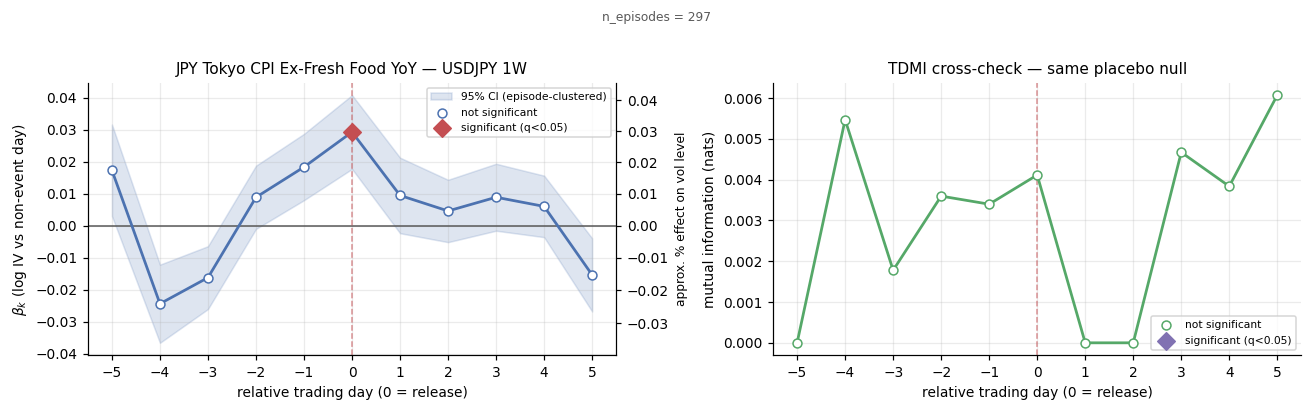

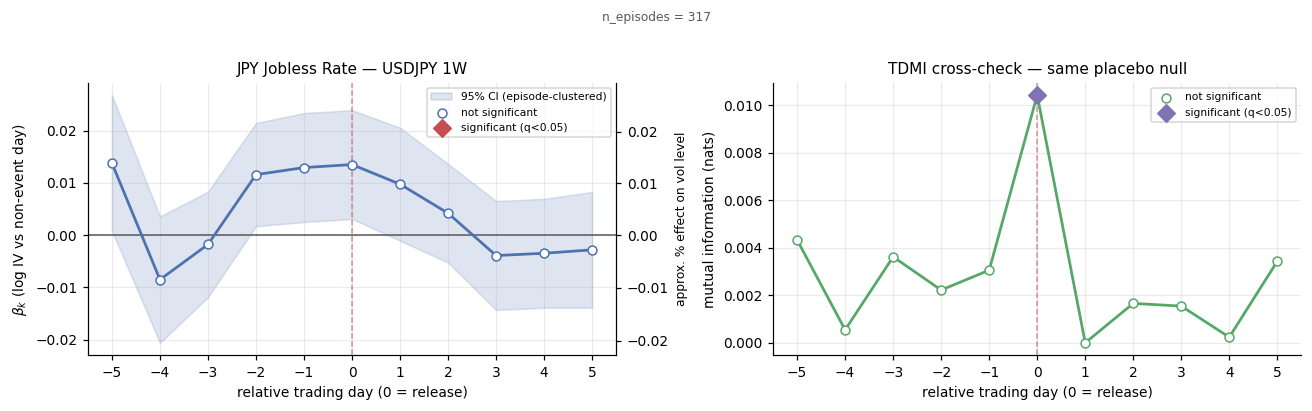

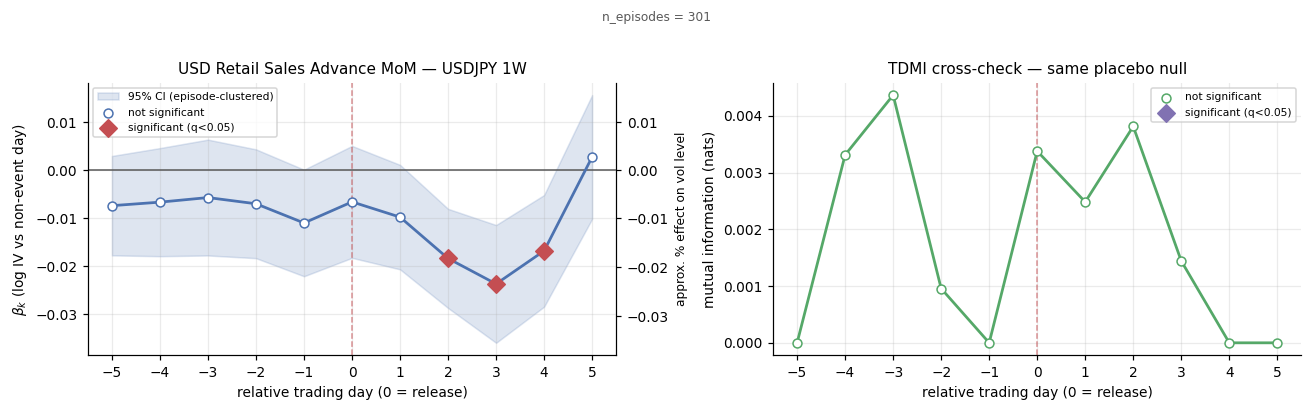

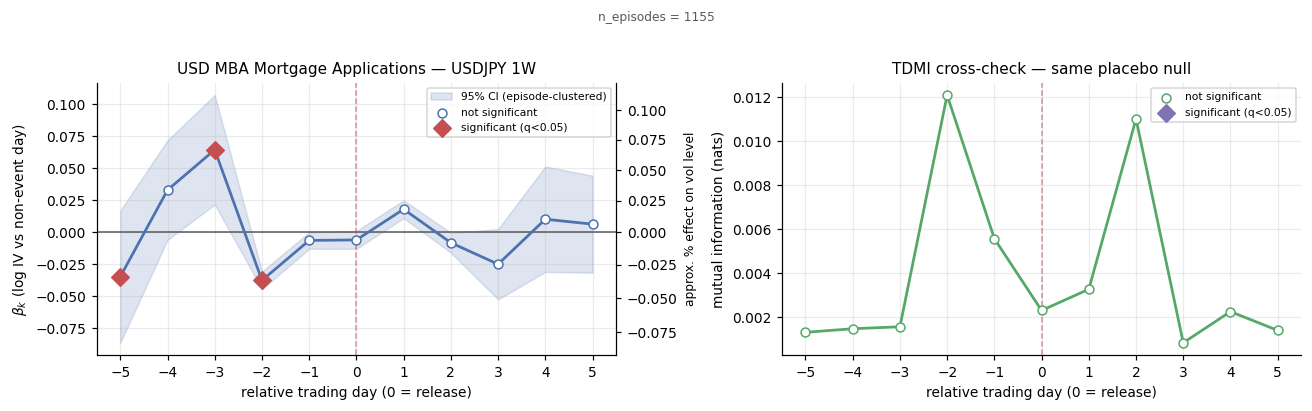

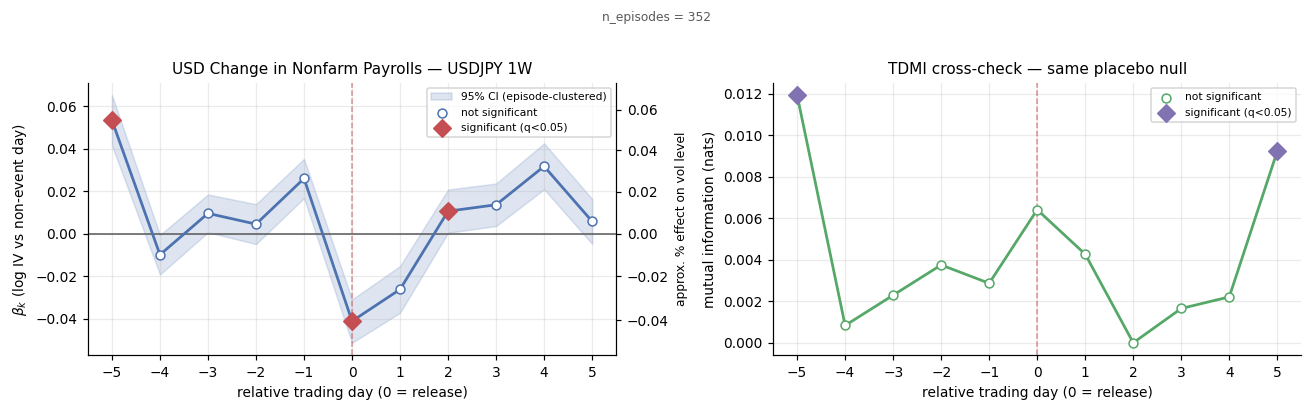

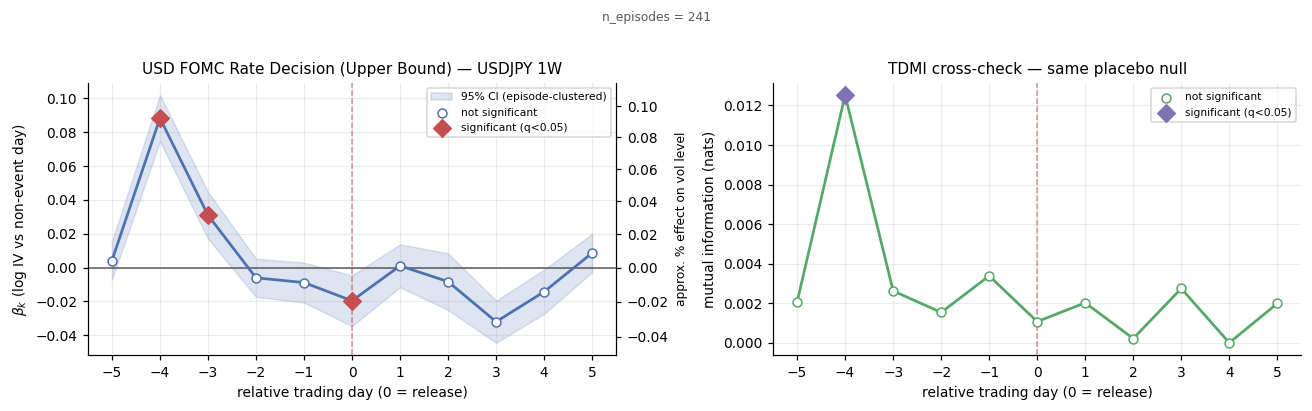

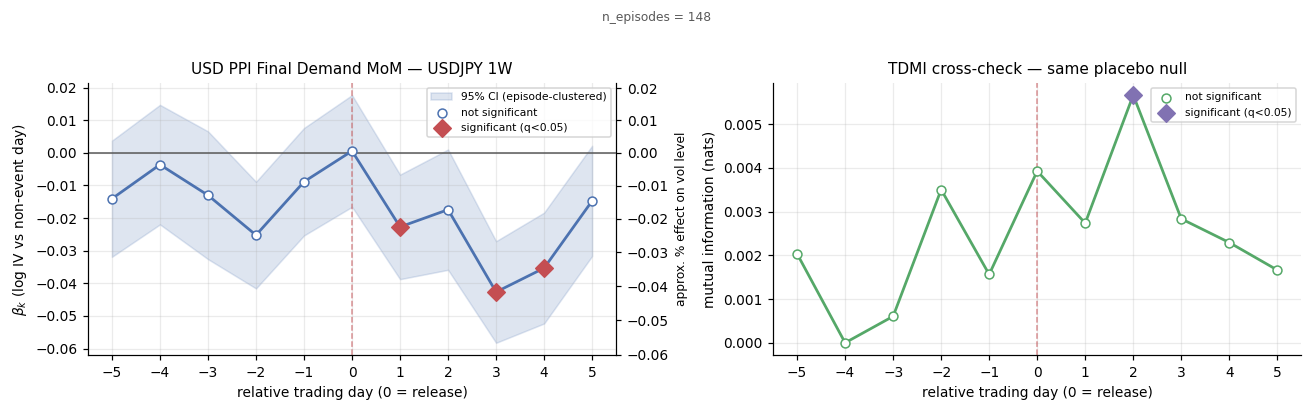

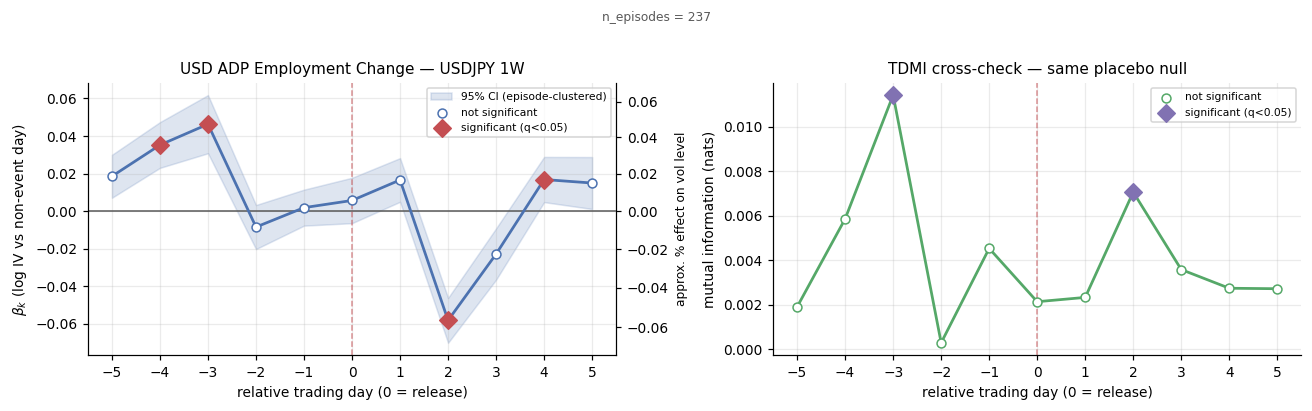

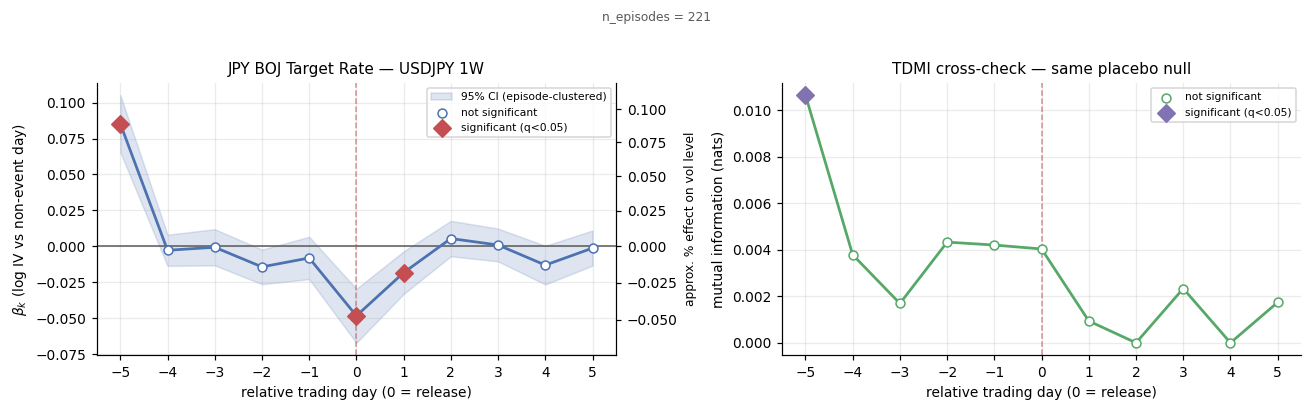

[2026-08-05 22:40:05] INFO  stage done : 9b. paired beta/MI plots (1.3s)


In [18]:
with stage("9b. paired beta/MI plots"):
    for key in STACK_KEYS:
        sub = days[(days["ccy"] == key[0]) & (days["event"] == key[1])].sort_values("relative_day")
        k = sub["relative_day"].values
        b, se = sub["beta"].values, sub["se"].values
        sb, sm_ = sub["significant_beta"].values, sub["significant_mi"].values
        mi_v = sub["mi"].values

        fig, axes = plt.subplots(1, 2, figsize=(12.0, 3.6))
        ax = axes[0]
        ax.axhline(0, color="0.35", lw=1)
        ax.axvline(0, color=C_SIG, lw=1, ls="--", alpha=0.6)
        ax.fill_between(k, b - CI_Z * se, b + CI_Z * se, color=C_BETA, alpha=0.18,
                        label="95% CI (episode-clustered)")
        ax.plot(k, b, color=C_BETA, lw=1.8, zorder=2)
        ax.scatter(k[~sb], b[~sb], s=34, facecolors="white", edgecolors=C_BETA, zorder=3,
                   label="not significant")
        ax.scatter(k[sb], b[sb], s=66, color=C_SIG, marker="D", zorder=4,
                   label=f"significant (q<{FDR_ALPHA})")
        ax.set_xlabel("relative trading day (0 = release)")
        ax.set_ylabel(r"$\beta_k$ (log IV vs non-event day)")
        ax.set_title(f"{key[0]} {key[1][:44]} — {PAIR} {TENOR}", fontsize=10)
        ax.set_xticks(STACK_KS)
        ax.legend(fontsize=7, loc="best")
        sec = ax.secondary_yaxis("right", functions=(lambda v: np.exp(v) - 1,
                                                     lambda v: np.log(v + 1)))
        sec.set_ylabel("approx. % effect on vol level", fontsize=8)

        ax = axes[1]
        ax.axvline(0, color=C_SIG, lw=1, ls="--", alpha=0.6)
        ax.plot(k, mi_v, color=C_MI, lw=1.8, zorder=2)
        ax.scatter(k[~sm_], mi_v[~sm_], s=34, facecolors="white", edgecolors=C_MI, zorder=3,
                   label="not significant")
        ax.scatter(k[sm_], mi_v[sm_], s=66, color=C_SIG_MI, marker="D", zorder=4,
                   label=f"significant (q<{FDR_ALPHA})")
        ax.set_xlabel("relative trading day (0 = release)")
        ax.set_ylabel("mutual information (nats)")
        ax.set_title("TDMI cross-check — same placebo null", fontsize=10)
        ax.set_xticks(STACK_KS)
        ax.legend(fontsize=7, loc="best")

        fig.suptitle(f"n_episodes = {frames[key]['n_episodes']}", y=1.02, fontsize=8,
                     color="0.35")
        plt.tight_layout()
        plt.show()

## 10. Light out-of-sample check

For every event type with `both_significant` evidence on at least one relative day: hold out
the **most recent 20% of episodes**, fit the day-dummy + AR(1) model on the earlier 80% of
the panel, then predict `log(IV)` on the held-out episodes' windows and compare RMSE against
a **naive AR(1)-only baseline** — the same model with no event structure at all — on exactly
the same rows.

The comparison is one-step-ahead: both models see yesterday's realised log IV, and the only
difference between them is whether they also know where today sits relative to a scheduled
release. That is the right contrast, because the calendar is genuinely known in advance
while yesterday's vol is genuinely observed.

**This is a single train/test split, not walk-forward validation.** One split, one cut point,
chronological. It is a scoped-down version of the fuller forecasting-accuracy step (step 2 of
the exercise), and it should be read as a directional sanity check on whether the in-sample
structure survives contact with data the model never saw — not as a validated forecasting
result. With a single split, an RMSE difference of a percent or two is well inside what a
different cut point could reverse.

In [19]:
oos = pd.DataFrame()

with stage("10. out-of-sample check"):
    oos_keys = [k for k in STACK_KEYS
                if ((days["ccy"] == k[0]) & (days["event"] == k[1])
                    & (days["reconciliation_flag"] == "both_significant")).any()]
    log(f"out-of-sample check on {len(oos_keys)} event types with both_significant evidence")

    rows = []
    for key in oos_keys:
        try:
            f = frames[key]
            anchors = np.sort(episodes[key])
            n_test = max(1, int(round(len(anchors) * OOS_HOLDOUT_FRAC)))
            train_anchors, test_anchors = anchors[:-n_test], anchors[-n_test:]
            if len(train_anchors) < MIN_OCCURRENCES:
                raise ValueError(f"only {len(train_anchors)} training episodes")

            cut_pos = test_anchors[0] - PRE_DAYS          # first row belonging to the holdout
            _, rel_train = assign_relative_days(train_anchors)
            _, rel_test  = assign_relative_days(test_anchors)

            tr = np.flatnonzero(USABLE & (np.arange(N_PANEL) < cut_pos))
            te = np.flatnonzero(USABLE & ~np.isnan(rel_test) & (np.arange(N_PANEL) >= cut_pos))
            if len(te) < len(STACK_KS) or len(tr) < 200:
                raise ValueError(f"train/test rows too thin ({len(tr)}/{len(te)})")

            # --- event model: day dummies + AR(1) ---
            Xtr, live = stack_design(rel_train[tr], LAG_ALL[tr])
            b_ev, *_ = np.linalg.lstsq(Xtr, Y_ALL[tr], rcond=None)
            Dte = day_dummies(rel_test[te])[:, live]
            Xte = np.column_stack([np.ones(len(te)), Dte, LAG_ALL[te]])
            rmse_ev = float(np.sqrt(np.mean((Y_ALL[te] - Xte @ b_ev) ** 2)))

            # --- naive baseline: AR(1) only, no event structure ---
            Xtr0 = np.column_stack([np.ones(len(tr)), LAG_ALL[tr]])
            b_0, *_ = np.linalg.lstsq(Xtr0, Y_ALL[tr], rcond=None)
            Xte0 = np.column_stack([np.ones(len(te)), LAG_ALL[te]])
            rmse_0 = float(np.sqrt(np.mean((Y_ALL[te] - Xte0 @ b_0) ** 2)))

            rows.append({"ccy": key[0], "event": key[1],
                         "n_train_episodes": len(train_anchors),
                         "n_test_episodes": len(test_anchors),
                         "test_rows": len(te),
                         "test_start": pd.Timestamp(PANEL_DATES[te[0]]).date(),
                         "rmse_event_model": rmse_ev, "rmse_ar1_only": rmse_0,
                         "rmse_improvement_pct": 100 * (rmse_0 - rmse_ev) / rmse_0,
                         "event_structure_helps": rmse_ev < rmse_0})
        except Exception as exc:
            log(f"OOS failed for {key[0]} {key[1]}: {type(exc).__name__}: {exc} -- skipping.",
                "ERROR")
            SKIPPED_EVENTS.setdefault(key, f"OOS failed: {type(exc).__name__}: {exc}")

    oos = pd.DataFrame(rows)
    if len(oos):
        oos = oos.sort_values("rmse_improvement_pct", ascending=False).reset_index(drop=True)
        print(f"Single chronological split, most recent {OOS_HOLDOUT_FRAC:.0%} of episodes held "
              "out. Positive improvement = the event structure forecasts better than AR(1) alone.")
        print(oos.to_string(index=False, float_format=lambda x: f"{x:8.4f}"))
        print(f"\nevent structure reduces held-out RMSE for "
              f"{int(oos['event_structure_helps'].sum())} of {len(oos)} event types tested.")
    else:
        print("No event type reached both_significant, so there is nothing to check "
              "out-of-sample.")

[2026-08-05 22:40:05] INFO  stage start: 10. out-of-sample check
[2026-08-05 22:40:05] INFO  out-of-sample check on 4 event types with both_significant evidence
Single chronological split, most recent 20% of episodes held out. Positive improvement = the event structure forecasts better than AR(1) alone.
ccy                            event  n_train_episodes  n_test_episodes  test_rows test_start  rmse_event_model  rmse_ar1_only  rmse_improvement_pct  event_structure_helps
JPY                  BOJ Target Rate               177               44        484 2021-01-14            0.1148         0.1235                6.9796                   True
USD FOMC Rate Decision (Upper Bound)               193               48        528 2020-07-22            0.1064         0.1133                6.1137                   True
USD       Change in Nonfarm Payrolls               282               70        770 2020-07-31            0.0980         0.1007                2.6588                   True
USD    

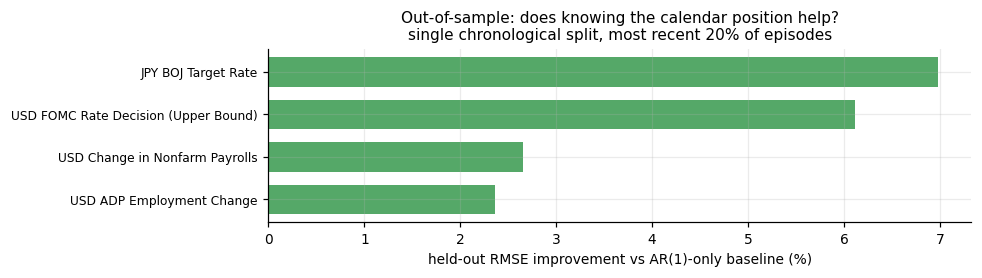

In [20]:
if len(oos):
    o = oos.sort_values("rmse_improvement_pct")
    fig, ax = plt.subplots(figsize=(9, max(2.6, 0.32 * len(o))))
    cols = [C_MI if h else C_MUTE for h in o["event_structure_helps"]]
    ax.barh(np.arange(len(o)), o["rmse_improvement_pct"], color=cols, height=0.7)
    ax.set_yticks(np.arange(len(o)))
    ax.set_yticklabels([f"{r.ccy} {r.event[:38]}" for r in o.itertuples()], fontsize=8)
    ax.axvline(0, color="0.35", lw=1)
    ax.set_xlabel("held-out RMSE improvement vs AR(1)-only baseline (%)")
    ax.set_title("Out-of-sample: does knowing the calendar position help?\n"
                 f"single chronological split, most recent {OOS_HOLDOUT_FRAC:.0%} of episodes",
                 fontsize=10)
    plt.tight_layout()
    plt.show()

## 11. Summary table

One row per selected event type, joining every stage: the step-5 screen verdict, the peak
relative day and its magnitude from step 9, the reconciliation counts, and the step-10
held-out RMSE comparison. Two CSVs are written — the full `(event, relative day)` grid with
every estimate, q-value and flag including non-significant ones, and this per-event summary.

The full grid keeps non-significant coefficients **at their estimated values** rather than
zeroing them. "We estimated +0.4% and cannot rule out zero" and "we estimated exactly zero"
are different statements, and which one to act on belongs to whoever reads the table.

In [21]:
summary = pd.DataFrame()
ARTIFACTS_OK = {}

with stage("11. summary table + CSV artifacts"):
    scr = screen.set_index(["ccy", "event"]) if len(screen) else pd.DataFrame()
    rec_counts = (days.groupby(["ccy", "event"])["reconciliation_flag"]
                  .value_counts().unstack(fill_value=0)) if len(days) else pd.DataFrame()

    rows = []
    for (c, e) in selected_events:
        key = (c, e)
        row = {"ccy": c, "event": e}
        row["in_analysis"] = key in STACK_KEYS
        if len(scr) and key in scr.index:
            s = scr.loc[key]
            row.update({"n_episodes": int(s["n_episodes"]), "screen_beta": s["beta"],
                        "screen_pct": s["effect_pct"], "screen_q": s["q"],
                        "screen_significant": bool(s["significant"])})
        else:
            row.update({"n_episodes": len(episodes_raw.get(key, [])), "screen_beta": np.nan,
                        "screen_pct": np.nan, "screen_q": np.nan, "screen_significant": False})
        pk = peak_summary[(peak_summary["ccy"] == c) & (peak_summary["event"] == e)]
        if len(pk):
            row.update({"peak_day": pk["peak_day"].iloc[0], "peak_beta": pk["peak_beta"].iloc[0],
                        "peak_pct": pk["peak_pct"].iloc[0],
                        "n_both_significant": int(pk["n_both_significant"].iloc[0])})
        else:
            row.update({"peak_day": np.nan, "peak_beta": np.nan, "peak_pct": np.nan,
                        "n_both_significant": 0})
        if len(rec_counts) and key in rec_counts.index:
            for flg in ["mi_only_distributional", "beta_only_review"]:
                row[f"n_{flg}"] = int(rec_counts.loc[key].get(flg, 0))
        else:
            row["n_mi_only_distributional"] = 0
            row["n_beta_only_review"] = 0
        oo = oos[(oos["ccy"] == c) & (oos["event"] == e)] if len(oos) else pd.DataFrame()
        if len(oo):
            row.update({"oos_rmse_event": oo["rmse_event_model"].iloc[0],
                        "oos_rmse_ar1": oo["rmse_ar1_only"].iloc[0],
                        "oos_improvement_pct": oo["rmse_improvement_pct"].iloc[0],
                        "oos_helps": bool(oo["event_structure_helps"].iloc[0])})
        else:
            row.update({"oos_rmse_event": np.nan, "oos_rmse_ar1": np.nan,
                        "oos_improvement_pct": np.nan, "oos_helps": np.nan})
        row["skip_reason"] = SKIPPED_EVENTS.get(key, "")
        rows.append(row)

    summary = (pd.DataFrame(rows)
               .sort_values(["n_both_significant", "screen_beta"], ascending=[False, False])
               .reset_index(drop=True))
    summary["model_version"] = "usdjpy_event_stack_causal_v1"
    summary["pair"] = PAIR
    summary["tenor"] = TENOR

    days_out = days.copy()
    days_out["pair"] = PAIR
    days_out["tenor"] = TENOR
    days_out["model_version"] = "usdjpy_event_stack_causal_v1"
    days_out["sample_start"] = pd.Timestamp(PANEL_DATES[0]).date()
    days_out["sample_end"] = pd.Timestamp(PANEL_DATES[-1]).date()

    for path, df in [(OUT_FULL_PATH, days_out), (OUT_SUMMARY_PATH, summary)]:
        try:
            df.to_csv(path, index=False)
            ARTIFACTS_OK[path] = os.path.isfile(path) and os.path.getsize(path) > 0
        except Exception as exc:
            ARTIFACTS_OK[path] = False
            log(f"failed to write {path}: {exc}", "ERROR")

    print(f"Wrote {OUT_FULL_PATH} ({len(days_out)} rows) -> ok={ARTIFACTS_OK[OUT_FULL_PATH]}")
    print(f"Wrote {OUT_SUMMARY_PATH} ({len(summary)} rows) -> ok={ARTIFACTS_OK[OUT_SUMMARY_PATH]}")
    print("\n" + "=" * 110)
    print(f"SUMMARY — {PAIR} {TENOR} implied vol, one row per selected event type")
    print("=" * 110)
    print(summary[["ccy", "event", "n_episodes", "screen_significant", "screen_pct",
                   "peak_day", "peak_pct", "n_both_significant", "n_mi_only_distributional",
                   "oos_improvement_pct", "oos_helps"]]
          .to_string(index=False, float_format=lambda x: f"{x:8.4f}"))

[2026-08-05 22:40:05] INFO  stage start: 11. summary table + CSV artifacts
Wrote /Users/aksharaa/Downloads/usdjpy_event_stack_full.csv (99 rows) -> ok=True
Wrote /Users/aksharaa/Downloads/usdjpy_event_stack_summary.csv (25 rows) -> ok=True

SUMMARY — USDJPY 1W implied vol, one row per selected event type
ccy                            event  n_episodes  screen_significant  screen_pct  peak_day  peak_pct  n_both_significant  n_mi_only_distributional  oos_improvement_pct oos_helps
USD            ADP Employment Change         237                True     -0.0123    2.0000   -0.0565                   2                         0               2.3646      True
USD       Change in Nonfarm Payrolls         352                True     -0.0113   -5.0000    0.0548                   1                         1               2.6588      True
USD FOMC Rate Decision (Upper Bound)         241                True     -0.0115   -4.0000    0.0923                   1                         0              

In [22]:
# ---- run summary: readable in 30 seconds, before anyone opens the notebook ----
total_min = (time.time() - RUN_T0) / 60
n_selected = len(selected_events)
n_completed = len(STACK_KEYS)
n_screen_pass = int(screen["significant"].sum()) if len(screen) else 0
has_flags = len(days) and "reconciliation_flag" in days.columns
n_both = int((days["reconciliation_flag"] == "both_significant").sum()) if has_flags else 0
n_both_events = int((summary["n_both_significant"] > 0).sum()) if len(summary) else 0
n_oos_help = int(oos["event_structure_helps"].sum()) if len(oos) else 0

lines = []
lines.append(f"RUN SUMMARY — usdjpy_event_stack_causal — {pd.Timestamp.now():%Y-%m-%d %H:%M:%S}")
lines.append("=" * 78)
lines.append(f"total runtime                     : {total_min:.1f} min")
lines.append(f"pair / tenor                      : {PAIR} / {TENOR}")
lines.append(f"panel                             : {len(panel)} trading days, "
             f"{panel.index.min():%Y-%m-%d} to {panel.index.max():%Y-%m-%d}")
lines.append(f"N_PERMUTATIONS                    : {N_PERMUTATIONS} "
             f"(NOT reduced at any point in this run)")
lines.append("")
lines.append(f"event types selected (relevance>={RELEVANCE_CUTOFF:g}) : {n_selected}")
lines.append(f"  ... after de-dup + MIN_OCCURRENCES={MIN_OCCURRENCES} : {len(EVENT_KEYS)}")
lines.append(f"  ... passed the event-vs-non-event screen  : {n_screen_pass}")
lines.append(f"  ... completed the full permutation grid   : {n_completed}")
lines.append(f"  ... skipped with a logged reason          : {len(SKIPPED_EVENTS)}")
lines.append("")
lines.append(f"(event, relative-day) cells tested          : {len(days)}")
lines.append(f"  both_significant (beta AND MI)            : {n_both} cells across "
             f"{n_both_events} event types")
lines.append(f"  mi_only_distributional                    : "
             f"{int((days['reconciliation_flag'] == 'mi_only_distributional').sum()) if has_flags else 0}")
lines.append(f"  beta_only_review                          : "
             f"{int((days['reconciliation_flag'] == 'beta_only_review').sum()) if has_flags else 0}")
lines.append(f"out-of-sample: event structure beat AR(1)   : {n_oos_help} of {len(oos)} tested")
lines.append("")
if len(summary) and summary["n_both_significant"].max() > 0:
    lines.append("peak days (both methods agree):")
    for r in summary[summary["n_both_significant"] > 0].itertuples():
        lines.append(f"  {r.ccy} {r.event[:44]:<44s} day {int(r.peak_day):+d}  "
                     f"{r.peak_pct:+.2%} vs a normal day")
    lines.append("")
if SKIPPED_EVENTS:
    lines.append("skipped event types and why:")
    for (c, e), reason in SKIPPED_EVENTS.items():
        lines.append(f"  {c} {e[:44]:<44s} {reason}")
    lines.append("")
if STAGE_ERRORS:
    lines.append("STAGE FAILURES (results below these stages may be incomplete):")
    for name, msg in STAGE_ERRORS:
        lines.append(f"  {name}: {msg}")
    lines.append("")
else:
    lines.append("stage failures: none — every stage completed.")
    lines.append("")
lines.append("artifacts:")
for path, ok in ARTIFACTS_OK.items():
    size = os.path.getsize(path) if os.path.isfile(path) else 0
    lines.append(f"  {'OK  ' if ok else 'FAIL'} {path} ({size} bytes)")
n_ckpt = len([f for f in os.listdir(CHECKPOINT_DIR) if f.startswith(f"{PAIR}_{TENOR}__")])
lines.append(f"  OK   {CHECKPOINT_DIR} ({n_ckpt} per-event checkpoints)")
lines.append(f"  OK   {RUN_LOG_PATH}")
lines.append("")
trust = "TRUSTWORTHY" if (not STAGE_ERRORS and n_completed > 0
                          and all(ARTIFACTS_OK.values())) else "NEEDS REVIEW"
lines.append(f"VERDICT: {trust}")
if trust != "TRUSTWORTHY":
    lines.append("  -> open _run_log.txt before reading any result above.")

with open(RUN_SUMMARY_PATH, "w") as fh:
    fh.write("\n".join(lines) + "\n")
print("\n".join(lines))
log(f"run summary written to {RUN_SUMMARY_PATH}")

RUN SUMMARY — usdjpy_event_stack_causal — 2026-08-05 22:40:05
total runtime                     : 5.0 min
pair / tenor                      : USDJPY / 1W
panel                             : 7828 trading days, 1995-12-06 to 2026-07-01
N_PERMUTATIONS                    : 200 (NOT reduced at any point in this run)

event types selected (relevance>=90) : 25
  ... after de-dup + MIN_OCCURRENCES=30 : 23
  ... passed the event-vs-non-event screen  : 9
  ... completed the full permutation grid   : 9
  ... skipped with a logged reason          : 14

(event, relative-day) cells tested          : 99
  both_significant (beta AND MI)            : 5 cells across 4 event types
  mi_only_distributional                    : 3
  beta_only_review                          : 18
out-of-sample: event structure beat AR(1)   : 4 of 4 tested

peak days (both methods agree):
  USD ADP Employment Change                        day +2  -5.65% vs a normal day
  USD Change in Nonfarm Payrolls                   day -5

## What this establishes — and what it does not

This notebook establishes a **historically repeatable association**: for the selected
high-relevance USD and JPY releases, USDJPY 1-week ATM implied volatility sits systematically
above or below an ordinary non-event day on specific trading days relative to the release
date — by more than a calendar-matched placebo produces, under two independent instruments
(a clustered mean-shift regression and a non-parametric mutual-information test), each
corrected flat for multiple testing across its own grid, and with the shape surviving a
single held-out forecast comparison against an AR(1)-only baseline.

That is a real and usable finding, and it is **not a structural causal effect**. There is no
counterfactual, no instrument, no randomisation — nobody assigned release dates at random.
The strongest honest reading is: *when this release is on the calendar, USDJPY 1W implied vol
has behaved this way around it, more reliably than chance placement of a similar set of dates
would produce.* Alternative explanations this design cannot separate include dealers marking
up event risk in advance (anticipation, not information), month-end and option-expiry cycles
that sit at the same fixed calendar points as many releases, and neighbouring releases — with
~25 event types on one pair's calendar, some windows overlap, and unlike the reference
notebook there is no concurrent-event control regressor here to absorb any of it. That
simplification is deliberate and it is a real limitation, not a neutral one.

And, restated because it is the boundary of the whole exercise: **outcome sensitivity was
never tested.** Nothing here says anything about whether a *large* surprise moves vol more
than a small one, whether the direction of the miss matters, or whether the reaction has
changed as the market's sensitivity to a given release has changed. `surprise_z` was never
loaded, and Granger causality — which would need exactly that kind of stochastic driver — was
never run. Those are the natural next study, and they are a different study.